# NeuralSS data pipeline: discovery, deduplication and leakage-safe splits (Kaggle GPU T4 x2)

**Goal.** Build the single dataset manifest used by both training notebooks of the NeuralSS stack
(temporal super-resolution and low-latency frame generation). Only Kaggle and Hugging Face datasets are used.

**Steps.**

1. Discover attached Kaggle datasets (capped, randomised directory walk) and drop degraded copies (LR, bicubic, blurred, `x2`/`x3`/`x4`) and non-colour passes.
2. Materialise selected Hugging Face subsets into `/kaggle/working/nss_data` with range requests and streaming (no full archive downloads): game frames, TartanAir sequences with depth, exact optical flow and occlusion masks, GameIR native 720p / 1440p game renders with depth, and 1080p Vimeo videos.
3. Group frames into sequences; every item gets a leakage group (sequence, video, scene family, environment or town).
4. Decode keyframes into thumbnails and compute quality statistics; filter too-small, flat, letterboxed and blurry items.
5. Perceptual near-duplicate detection across the whole combined dataset: 64-bit DCT pHash and dHash plus DINOv2-small embeddings, exhaustive GPU nearest-neighbour search on both GPUs, thresholds calibrated on synthetic positive pairs (crops, rescales, JPEG, colour shifts, mirroring, overlays) at a 0.1 percent false-positive rate.
6. Union-find clustering of duplicate edges and leakage groups; one split per component. Components that touch a test item become test and their training members are dropped.
7. Audit: nearest training neighbour of every validation and test keyframe; save the manifest, reports, plots and a dataset card with licences.

**Outputs** (in `/kaggle/working`, saved as this notebook's output; attach it to the training notebooks with **Add Input > Notebook output**):

```text
nss_data/nss_manifest.parquet   one row per still or sequence: source, frames (URIs), motion / depth / mask URIs, group, split, component
nss_data/<hf subsets>/          materialised Hugging Face data referenced by the manifest
metrics/                        discovery, statistics, calibration, duplicate pairs, split and audit reports, dataset card
plots/                          every figure as PNG
logs/notebook.log
outputs.zip                     metrics, plots and logs (the data itself is already in the Output tab)
```

**Required Kaggle settings.** Accelerator **GPU T4 x2**; **Internet on** (Hugging Face data and DINOv2 weights); optional secret `HF_TOKEN` (higher Hub rate limits). Attach these Kaggle datasets:

| Kaggle dataset | Use |
| :--- | :--- |
| `soumikrakshit/div2k-high-resolution-images` | stills; `DIV2K_valid_HR` pinned to test |
| `daehoyang/flickr2k` | stills |
| `amithkesavmrajagiri/reds-dataset` | 720p video sequences |
| `wangsally/vimeo-90k-7` | 448x256 septuplets |
| `chenshu123/vimeo-triplet` | frame-generation test (official test list when present) |
| `artemmmtry/mpi-sintel-dataset` | rendered sequences with exact flow and occlusions (scene families `market`, `cave` pinned to test) |
| `uom200647r/vid4-dataset` | video test only |

**Run time.** About 1.5 to 2.5 hours (most of it Hugging Face transfer and decoding). `QUICK_RUN = True` shrinks every cap for a 20-minute smoke test.

## 1. Library files

The pipeline code is shared with the two training notebooks. The first cell creates `/kaggle/working/code`, then the following cells write the library into it so the notebook is self-contained: `nss_common` (run folders, logging, stage timer, zip), `nss_data` (source registry, discovery, Hugging Face range-request access, decoding, windows), `nss_dedup` (hashes, embeddings, calibration, GPU neighbour search, union-find split) and `nss_pipeline` (the steps run below).

In [1]:
import os

os.makedirs(
    "/kaggle/working/code", exist_ok=True
)  # %%writefile does not create folders

**`nss_common.py`**: run folders, logger, stage timer, figure and metric saving, hardware report, pip helper and the training-process launcher.

In [2]:
%%writefile /kaggle/working/code/nss_common.py
"""Shared notebook runtime: output folders, logging, stage timing, figure saving, hardware report, pip helper."""

import importlib
import json
import logging
import os
import shutil
import subprocess
import sys
import time
from contextlib import contextmanager
from pathlib import Path

import matplotlib.pyplot as plt
import psutil
import torch

WORK = Path("/kaggle/working")
INPUT_ROOT = Path("/kaggle/input")
SUBDIRS = ["code", "weights", "plots", "metrics", "logs", "predictions"]


class Run:
    """Holds the run clock, output folders, logger and per-stage timings of one notebook run."""

    def __init__(self, name, work=WORK):
        self.start = time.time()
        self.work = Path(work)
        self.dirs = {d: self.work / d for d in SUBDIRS}
        for folder in self.dirs.values():
            folder.mkdir(parents=True, exist_ok=True)
        self.log = logging.getLogger(name)
        self.log.setLevel(logging.INFO)
        self.log.handlers.clear()
        self.log.propagate = False
        for handler in (
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(self.dirs["logs"] / "notebook.log"),
        ):
            handler.setFormatter(
                logging.Formatter("%(asctime)s | %(message)s", "%H:%M:%S")
            )
            self.log.addHandler(handler)
        self.stage_times = {}

    def hours(self):
        return (time.time() - self.start) / 3600

    @contextmanager
    def stage(self, name):
        t0 = time.time()
        self.log.info("start: %s", name)
        try:
            yield
        finally:
            self.stage_times[name] = time.time() - t0
            self.log.info(
                "done: %s in %.1f min (run total %.2f h)",
                name,
                self.stage_times[name] / 60,
                self.hours(),
            )

    def show(self, fig, name):
        from IPython.display import display

        fig.savefig(self.dirs["plots"] / f"{name}.png", dpi=120, bbox_inches="tight")
        display(fig)
        plt.close(fig)

    def save_json(self, obj, name):
        with open(self.dirs["metrics"] / name, "w") as f:
            json.dump(obj, f, indent=2, default=str)

    def save_csv(self, df, name, **kwargs):
        df.to_csv(self.dirs["metrics"] / name, **kwargs)


def hardware_report(work=WORK):
    """GPU, CPU, RAM and disk detected at run time (nothing hard-coded)."""
    gpus = []
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        gpus.append(
            {
                "gpu": i,
                "name": p.name,
                "vram_gb": round(p.total_memory / 2**30, 2),
                "sm": p.multi_processor_count,
                "cc": f"{p.major}.{p.minor}",
            }
        )
    vm = psutil.virtual_memory()
    report = {
        "gpus": len(gpus),
        "gpu_list": gpus,
        "cpu_count": os.cpu_count(),
        "ram_total_gb": round(vm.total / 2**30, 1),
        "ram_available_gb": round(vm.available / 2**30, 1),
        "disk_free_gb_working": round(shutil.disk_usage(work).free / 2**30, 1),
        "disk_free_gb_tmp": (
            round(shutil.disk_usage("/tmp").free / 2**30, 1)
            if Path("/tmp").exists()
            else None
        ),
        "python": sys.version.split()[0],
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
    }
    return report


def pip_install(packages, log=None):
    """Install missing packages quietly; returns {package: importable}. Needs Kaggle Internet on."""
    status = {}
    for pip_name, module in packages.items():
        try:
            importlib.import_module(module)
            status[pip_name] = True
            continue
        except ImportError:
            pass
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", pip_name],
            capture_output=True,
            text=True,
        )
        try:
            importlib.invalidate_caches()
            importlib.import_module(module)
            status[pip_name] = True
        except ImportError:
            status[pip_name] = False
            if log:
                log.warning(
                    "could not install %s: %s", pip_name, result.stderr.strip()[-300:]
                )
    return status


def gpu_utilisation():
    try:
        out = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=utilization.gpu,memory.used",
                "--format=csv,noheader,nounits",
            ],
            capture_output=True,
            text=True,
            timeout=10,
        ).stdout
        return [
            [float(v) for v in line.split(",")] for line in out.strip().splitlines()
        ]
    except Exception:
        return []


def stream_process(cmd, env, on_line, log_path):
    """Run a subprocess, call on_line for every stdout line, mirror everything into log_path; returns exit code."""
    with open(log_path, "w") as logf:
        proc = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
            env=env,
        )
        for line in proc.stdout:
            logf.write(line)
            logf.flush()
            on_line(line.rstrip("\n"))
        return proc.wait()


def launch_training(
    script, cfg, cfg_path, log_path, gpus, desc, port=29500, on_round=None
):
    """Run a training script on the given GPUs (torch.distributed.run for several GPUs, a plain process for one),
    write its config, mirror its output to log_path, drive a tqdm bar from PROGRESS lines and collect ROUND rows.
    Returns (rounds, done). Raises with the log tail if the process fails."""
    from tqdm.auto import tqdm

    with open(cfg_path, "w") as f:
        json.dump(cfg, f, indent=2)
    env = os.environ.copy()
    env.update(
        {
            "NCCL_P2P_DISABLE": "1",
            "OMP_NUM_THREADS": "1",
            "PYTHONUNBUFFERED": "1",
            "CUDA_VISIBLE_DEVICES": ",".join(str(g) for g in gpus),
        }
    )
    if len(gpus) > 1:
        cmd = [
            sys.executable,
            "-m",
            "torch.distributed.run",
            f"--nproc_per_node={len(gpus)}",
            f"--master_port={port}",
            str(script),
            "--config",
            str(cfg_path),
        ]
    else:
        env["CUDA_DEVICE"] = "0"
        cmd = [sys.executable, str(script), "--config", str(cfg_path)]
    rounds, done, tail = [], {}, []
    bar = tqdm(
        total=100,
        desc=desc,
        unit="%",
        bar_format="{l_bar}{bar}| {n:.0f}/{total:.0f}% [{elapsed}<{remaining}] {postfix}",
    )

    def on_line(line):
        tail.append(line)
        del tail[:-40]
        kind, _, payload = line.partition(" ")
        if kind in ("PROGRESS", "ROUND", "DONE", "LOG"):
            try:
                data = json.loads(payload)
            except ValueError:
                return
            if kind == "PROGRESS":
                bar.n = round(100 * data["progress"], 1)
                bar.set_postfix(
                    loss=f"{data['loss']:.4f}",
                    sps=f"{data['samples_per_s']:.0f}",
                    lr=f"{data['lr']:.1e}",
                    mem=data["mem_gb"],
                )
                bar.refresh()
            elif kind == "ROUND":
                rounds.append(data)
                if on_round:
                    on_round(rounds)
            elif kind == "DONE":
                done.update(data)
            else:
                print(f"[{desc}] {data.get('msg')}", flush=True)
        elif "Error" in line or "Traceback" in line:
            print(f"[{desc}] {line}", flush=True)

    code = stream_process(cmd, env, on_line, log_path)
    bar.n = 100
    bar.close()
    if code != 0:
        raise RuntimeError(
            f"{desc} failed with exit code {code}; last lines:\n"
            + "\n".join(tail[-15:])
        )
    return rounds, done

Writing /kaggle/working/code/nss_common.py


**`nss_data.py`**: source registry (Kaggle and Hugging Face), capped discovery, HTTP range-request access to remote archives, Hugging Face materialisation, decoding of colour / depth / flow / masks, window and crop workers, manifest I/O.

In [3]:
%%writefile /kaggle/working/code/nss_data.py
"""Unified dataset layer: source registry (Kaggle + Hugging Face), discovery, filtering, materialisation of
Hugging Face subsets, sequence building, decoding of colour / depth / flow / masks, and window extraction.

URI scheme used in the manifest (so it stays valid across notebooks and machines):
  kaggle:<owner/slug>|<path inside the dataset>   resolved under /kaggle/input
  data:<relative path>                            resolved under the data root (materialised Hugging Face subsets)
  mp4:<relative path>#<frame index>               a frame of a video file under the data root
"""

import hashlib
import io
import json
import os
import random
import re
import tarfile
import time
import urllib.parse
import urllib.request
import zipfile
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
from PIL import Image

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff", ".ppm"}
# Path tokens that mark degraded copies or non-colour passes; such files are never used as targets.
LOW_QUALITY_TOKEN = re.compile(
    r"^(lr\d*|lq|low|lowres|bicubic|bix\d|bdx\d|lrbi|lrbd|x\d|blur|blurred|noisy|compressed|jpeg)$"
)
NON_COLOUR_TOKENS = {
    "occlusions",
    "occlusion",
    "invalid",
    "flow",
    "flow_viz",
    "viz",
    "mask",
    "masks",
    "depth",
    "albedo",
    "shading",
    "disparities",
    "segmentation",
    "camdata",
    "camdata_left",
    "edges",
    "normals",
    "seg",
}
HR_TOKENS = {"hr", "gt", "original", "groundtruth"}
HF = "https://huggingface.co"

# ---------------------------------------------------------------------------------------------------------------
# Source registry. Every source states where it lives, what it provides and how it may be used.
# role: train sources are split into train/val by leakage group; test sources (or test parts) are pinned to test.
# ---------------------------------------------------------------------------------------------------------------
SOURCES = [
    {
        "name": "div2k",
        "host": "kaggle",
        "ref": "soumikrakshit/div2k-high-resolution-images",
        "kind": "still",
        "test_dirs": ["DIV2K_valid_HR"],
        "licence": "DIV2K: academic research use",
        "content": "photo",
    },
    {
        "name": "flickr2k",
        "host": "kaggle",
        "ref": "daehoyang/flickr2k",
        "kind": "still",
        "licence": "Flickr2K: research use (Flickr images, original licences)",
        "content": "photo",
    },
    {
        "name": "reds",
        "host": "kaggle",
        "ref": "amithkesavmrajagiri/reds-dataset",
        "kind": "video",
        "group_level": 1,
        "licence": "REDS: CC BY 4.0",
        "content": "video",
    },
    {
        "name": "vimeo_septuplet",
        "host": "kaggle",
        "ref": "wangsally/vimeo-90k-7",
        "kind": "video",
        "group_level": 2,
        "licence": "Vimeo-90K: research use (Vimeo uploads)",
        "content": "video",
    },
    {
        "name": "vimeo_triplet",
        "host": "kaggle",
        "ref": "chenshu123/vimeo-triplet",
        "kind": "video",
        "group_level": 2,
        "test_list": "tri_testlist.txt",
        "test_only": True,
        "list_cap": 6000,
        "max_items": 1000,
        "licence": "Vimeo-90K: research use",
        "content": "video",
    },
    {
        "name": "sintel",
        "host": "kaggle",
        "ref": "artemmmtry/mpi-sintel-dataset",
        "kind": "render_seq",
        "test_groups": ["market", "cave"],
        "licence": "MPI Sintel: CC BY 3.0 (Kaggle mirror)",
        "content": "rendered",
    },
    {
        "name": "vid4",
        "host": "kaggle",
        "ref": "uom200647r/vid4-dataset",
        "kind": "video",
        "group_level": 1,
        "test_only": True,
        "licence": "Vid4: research benchmark (Kaggle mirror Apache 2.0)",
        "content": "video",
    },
    {
        "name": "game_stills",
        "host": "hf",
        "repo": "ericphann/video-game-super-resolution",
        "kind": "still",
        "train_dir": "training-hr",
        "test_dir": "test-hr",
        "licence": "HF tag Apache 2.0 (game captures; check per use)",
        "content": "game",
    },
    {
        "name": "tartanair",
        "host": "hf",
        "repo": "theairlabcmu/tartanair",
        "kind": "render_seq",
        "train_envs": [
            "abandonedfactory",
            "amusement",
            "carwelding",
            "endofworld",
            "gascola",
            "hospital",
            "neighborhood",
            "oldtown",
            "seasonsforest",
            "soulcity",
            "westerndesert",
            "ocean",
        ],
        "test_envs": ["japanesealley", "seasidetown"],
        "licence": "TartanAir: BSD-3-Clause (HF tag and tools)",
        "content": "rendered",
    },
    {
        "name": "gameir",
        "host": "hf",
        "repo": "LLLebin/GameIR",
        "kind": "render_pairs",
        "train_tars": ["mini_dataset/train/GameIR-SR/GameIR-SR-000000.tar"],
        "test_tars": ["mini_dataset/test/GameIR-SR/GameIR-SR-000000.tar"],
        "licence": "GameIR: MIT",
        "content": "game",
    },
    {
        "name": "vimeo1080p",
        "host": "hf",
        "repo": "danjacobellis/vimeo1080p",
        "kind": "video_file",
        "train_shards": [
            "data/train-00000-of-00045.parquet",
            "data/train-00001-of-00045.parquet",
        ],
        "val_shards": ["data/validation-00000-of-00003.parquet"],
        "licence": "unspecified on HF (Vimeo uploads); research use",
        "content": "video",
    },
]


def source(name):
    return next(s for s in SOURCES if s["name"] == name)


# ---------------------------------------------------------------------------------------------------------------
# Path utilities (Kaggle mounts)
# ---------------------------------------------------------------------------------------------------------------
def tokens(text):
    return [t for t in re.split(r"[_\-\s.]+", text.lower()) if t]


def path_tokens(path, root):
    rel = Path(path).relative_to(root)
    parts = list(rel.parts[:-1]) + [Path(rel.parts[-1]).stem]
    return [t for part in parts for t in tokens(part)]


def is_clean_colour(path, root):
    return not any(
        LOW_QUALITY_TOKEN.match(t) or t in NON_COLOUR_TOKENS
        for t in path_tokens(path, root)
    )


def find_dataset_root(input_root, owner_slug):
    """Mount folder of a Kaggle dataset under either supported layout, or None."""
    owner, slug = owner_slug.split("/")
    input_root = Path(input_root)
    for candidate in (
        input_root / slug,
        input_root / "datasets" / owner / slug,
        input_root / "datasets" / slug,
    ):
        if candidate.is_dir():
            return candidate
    for depth_one in input_root.iterdir() if input_root.is_dir() else []:
        if depth_one.is_dir():
            for depth_two in [depth_one] + [
                p for p in depth_one.iterdir() if p.is_dir()
            ]:
                if depth_two.name == slug:
                    return depth_two
    return None


def sampled_walk(root, max_files, seed, exts=IMG_EXTS):
    """List files, expanding a random directory from the frontier each step, so a capped listing spans many
    sequences. Each directory is listed completely, so a listed sequence folder is never cut in half.
    """
    rng = random.Random(seed)
    frontier, files, dirs_listed = [str(root)], [], 0
    while frontier and len(files) < max_files:
        i = rng.randrange(len(frontier))
        frontier[i], frontier[-1] = frontier[-1], frontier[i]
        current = frontier.pop()
        try:
            entries = list(os.scandir(current))
        except OSError:
            continue
        dirs_listed += 1
        for entry in entries:
            if entry.name.startswith("."):
                continue
            if entry.is_dir(follow_symlinks=False):
                frontier.append(entry.path)
            elif os.path.splitext(entry.name)[1].lower() in exts:
                files.append(entry.path)
    return sorted(files), dirs_listed, len(frontier) == 0


def natural_key(path):
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", str(path).lower())]


def stable_hash(text):
    return int(hashlib.md5(text.encode()).hexdigest(), 16)


# ---------------------------------------------------------------------------------------------------------------
# Hugging Face access: plain HTTPS with retries and range requests (no local Hub cache, works for Xet-backed files)
# ---------------------------------------------------------------------------------------------------------------
def _headers():
    token = os.environ.get("HF_TOKEN")
    return {"Authorization": f"Bearer {token}"} if token else {}


def hf_url(repo, path):
    return f"{HF}/datasets/{repo}/resolve/main/{urllib.parse.quote(path)}"


def http_get(url, headers=None, retries=4, timeout=120):
    for attempt in range(retries):
        try:
            req = urllib.request.Request(url, headers={**_headers(), **(headers or {})})
            with urllib.request.urlopen(req, timeout=timeout) as r:
                return r.read(), r.headers
        except Exception:
            if attempt == retries - 1:
                raise
            time.sleep(2**attempt)


def http_download(url, dest, retries=4):
    dest = Path(dest)
    if dest.exists() and dest.stat().st_size > 0:
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix(dest.suffix + ".part")
    for attempt in range(retries):
        try:
            req = urllib.request.Request(url, headers=_headers())
            with urllib.request.urlopen(req, timeout=300) as r, open(tmp, "wb") as f:
                while True:
                    chunk = r.read(1 << 22)
                    if not chunk:
                        break
                    f.write(chunk)
            tmp.rename(dest)
            return dest
        except Exception:
            if attempt == retries - 1:
                raise
            time.sleep(2**attempt)


def hf_list(repo, path=""):
    """All entries under a dataset folder (follows pagination)."""
    url = f"{HF}/api/datasets/{repo}/tree/main/{urllib.parse.quote(path)}"
    out = []
    while url:
        body, headers = http_get(url)
        out.extend(json.loads(body))
        link = headers.get("Link") or ""
        m = re.search(r'<([^>]+)>;\s*rel="next"', link)
        url = m.group(1) if m else None
    return out


class HttpRangeFile(io.RawIOBase):
    """Seekable read-only file over HTTP range requests, so zip members can be read without downloading archives."""

    def __init__(self, url):
        self.url, self.pos = url, 0
        req = urllib.request.Request(url, method="HEAD", headers=_headers())
        with urllib.request.urlopen(req, timeout=60) as r:
            self.size = int(r.headers["Content-Length"])
            self.url = r.url

    def seekable(self):
        return True

    def readable(self):
        return True

    def tell(self):
        return self.pos

    def seek(self, offset, whence=0):
        self.pos = {0: offset, 1: self.pos + offset, 2: self.size + offset}[whence]
        return self.pos

    def read(self, n=-1):
        if n is None or n < 0:
            n = self.size - self.pos
        n = min(n, self.size - self.pos)
        if n <= 0:
            return b""
        data, _ = http_get(
            self.url, headers={"Range": f"bytes={self.pos}-{self.pos + n - 1}"}
        )
        self.pos += len(data)
        return data

    def readinto(self, b):
        data = self.read(len(b))
        b[: len(data)] = data
        return len(data)


def remote_zip(url):
    return zipfile.ZipFile(io.BufferedReader(HttpRangeFile(url), buffer_size=1 << 20))


# ---------------------------------------------------------------------------------------------------------------
# Decoding
# ---------------------------------------------------------------------------------------------------------------
class Resolver:
    """Maps manifest URIs to local paths."""

    def __init__(self, data_root, input_root="/kaggle/input"):
        self.data_root, self.input_root, self.roots = (
            Path(data_root),
            Path(input_root),
            {},
        )

    def kaggle_root(self, ref):
        if ref not in self.roots:
            self.roots[ref] = find_dataset_root(self.input_root, ref)
        return self.roots[ref]

    def path(self, uri):
        if uri.startswith("kaggle:"):
            ref, rel = uri[7:].split("|", 1)
            root = self.kaggle_root(ref)
            if root is None:
                raise FileNotFoundError(f"Kaggle dataset {ref} is not attached")
            return root / rel
        if uri.startswith("data:"):
            return self.data_root / uri[5:]
        if uri.startswith("mp4:"):
            return self.data_root / uri[4:].split("#")[0]
        raise ValueError(uri)


def kaggle_uri(ref, root, path):
    return f"kaggle:{ref}|{Path(path).relative_to(root).as_posix()}"


def read_video_frames(path, indices):
    import cv2

    cap = cv2.VideoCapture(str(path))
    frames, want = {}, sorted(set(indices))
    if want:
        cap.set(cv2.CAP_PROP_POS_FRAMES, want[0])
        idx = want[0]
        while idx <= want[-1]:
            ok, frame = cap.read()
            if not ok:
                break
            if idx in want:
                frames[idx] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            idx += 1
    cap.release()
    missing = [i for i in indices if i not in frames]
    if missing:
        raise IOError(f"could not decode frames {missing[:3]} of {path}")
    return [frames[i] for i in indices]


def video_frame_count(path):
    import cv2

    cap = cv2.VideoCapture(str(path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return n


def load_rgb(resolver, uri):
    if uri.startswith("mp4:"):
        return read_video_frames(resolver.path(uri), [int(uri.split("#")[1])])[0]
    with Image.open(resolver.path(uri)) as im:
        return np.asarray(im.convert("RGB"))


def load_rgb_many(resolver, uris):
    """Decode a list of frames, reading each video file once."""
    if (
        uris
        and all(u.startswith("mp4:") for u in uris)
        and len({u.split("#")[0] for u in uris}) == 1
    ):
        return read_video_frames(
            resolver.path(uris[0]), [int(u.split("#")[1]) for u in uris]
        )
    return [load_rgb(resolver, u) for u in uris]


def read_flo(path):
    """Middlebury .flo (Sintel): float32 (H, W, 2)."""
    with open(path, "rb") as f:
        magic = np.frombuffer(f.read(4), np.float32)[0]
        assert abs(magic - 202021.25) < 1e-3, f"bad .flo magic in {path}"
        w, h = np.frombuffer(f.read(8), np.int32)
        return np.frombuffer(f.read(), np.float32).reshape(h, w, 2).copy()


def load_flow(resolver, uri):
    p = resolver.path(uri)
    return read_flo(p) if p.suffix == ".flo" else np.load(p).astype(np.float32)


def load_valid(resolver, uri, kind):
    """Validity of the motion vector of each pixel (1 = the pixel is visible in the previous frame)."""
    p = resolver.path(uri)
    with Image.open(p) as im:
        a = np.asarray(im.convert("L"))
    return (
        (a < 128).astype(np.uint8)
        if kind == "occlusion"
        else (a >= 128).astype(np.uint8)
    )


def decode_carla_depth(rgba):
    """CARLA depth PNG (R + 256 G + 65536 B) / (2^24 - 1) * 1000 m."""
    rgb = rgba[..., :3].astype(np.float64)
    norm = (rgb[..., 0] + rgb[..., 1] * 256.0 + rgb[..., 2] * 65536.0) / (256.0**3 - 1)
    return (norm * 1000.0).astype(np.float32)


def load_depth(resolver, uri):
    p = resolver.path(uri)
    if p.suffix == ".npy":
        return np.load(p).astype(np.float32)
    with Image.open(p) as im:
        return decode_carla_depth(np.asarray(im.convert("RGBA")))


def normalise_depth(d):
    """Unit-free inverse-depth style encoding in [0, 1] (1 = near): 1 / (1 + d / median)."""
    d = np.where(np.isfinite(d) & (d > 0), d, np.nan)
    med = np.nanmedian(d) if np.isfinite(d).any() else 1.0
    out = 1.0 / (1.0 + np.nan_to_num(d, nan=1e9) / max(med, 1e-6))
    return out.astype(np.float32)


# ---------------------------------------------------------------------------------------------------------------
# Catalogue builders: each returns a list of item dicts (one per still image or per sequence)
# ---------------------------------------------------------------------------------------------------------------
def _item(src, kind, group, frames, role, **extra):
    item_id = (
        f"{src['name']}/{group}/{hashlib.md5(frames[0].encode()).hexdigest()[:10]}"
    )
    return {
        "item_id": item_id,
        "source": src["name"],
        "kind": kind,
        "group": f"{src['name']}:{group}",
        "role": role,
        "frames": frames,
        "n_frames": len(frames),
        "content": src.get("content", ""),
        **extra,
    }


def catalogue_kaggle(src, input_root, cap, seed):
    """Stills and frame folders of a Kaggle-mounted source, with the degraded-copy filter."""
    root = find_dataset_root(input_root, src["ref"])
    if root is None:
        return [], {"found": False}
    files, dirs_listed, complete = sampled_walk(root, src.get("list_cap", cap), seed)
    kept = [f for f in files if is_clean_colour(f, root)]
    if src["kind"] in ("video",) and any(
        any(t in HR_TOKENS for t in path_tokens(f, root)) for f in kept
    ):
        kept = [f for f in kept if any(t in HR_TOKENS for t in path_tokens(f, root))]
    items = []
    if src["kind"] == "still":
        for f in kept:
            rel = Path(f).relative_to(root)
            role = (
                "test"
                if any(d in rel.parts for d in src.get("test_dirs", []))
                else "train"
            )
            items.append(
                _item(
                    src, "still", Path(f).stem, [kaggle_uri(src["ref"], root, f)], role
                )
            )
    elif src["kind"] == "video":
        test_set = set()
        if src.get("test_list"):
            lists = sorted(Path(root).rglob(src["test_list"]))
            if lists:
                test_set = {
                    line.strip()
                    for line in lists[0].read_text().splitlines()
                    if line.strip()
                }
        folders = {}
        for f in kept:
            folders.setdefault(str(Path(f).parent), []).append(f)
        for folder, frames in folders.items():
            frames = sorted(frames, key=natural_key)
            if len(frames) < 3:
                continue
            p = Path(folder)
            if p.name.lower() in HR_TOKENS:
                p = p.parent
            level = src.get("group_level", 1)
            group = p.name if level == 1 else p.parent.name
            clip_key = f"{p.parent.name}/{p.name}"
            if src.get("test_only"):
                if test_set and clip_key not in test_set:
                    continue
                role = "test"
            else:
                role = "train"
            items.append(
                _item(
                    src,
                    "seq",
                    group,
                    [kaggle_uri(src["ref"], root, f) for f in frames],
                    role,
                    mv="none",
                )
            )
    elif src["name"] == "sintel":
        items = catalogue_sintel(src, root)
    if src.get("max_items") and len(items) > src["max_items"]:
        items = random.Random(seed).sample(items, src["max_items"])
    return items, {
        "found": True,
        "listed": len(files),
        "kept_files": len(kept),
        "dirs_listed": dirs_listed,
        "listing_complete": complete,
    }


def catalogue_sintel(src, root):
    """Sintel training scenes with exact forward flow and occlusion masks. The leakage group is the scene prefix
    (alley, ambush, market, ...) because numbered scenes share sets and characters."""
    items = []
    for pass_dir in sorted(Path(root).rglob("training/clean")) + sorted(
        Path(root).rglob("training/final")
    ):
        train_root = pass_dir.parent
        for scene in sorted(p for p in pass_dir.iterdir() if p.is_dir()):
            frames = sorted(scene.glob("*.png"), key=natural_key)
            flows = [
                train_root / "flow" / scene.name / (f.stem + ".flo") for f in frames
            ]
            occ = [train_root / "occlusions" / scene.name / f.name for f in frames]
            if len(frames) < 4 or not flows[0].exists():
                continue
            prefix = scene.name.split("_")[0]
            role = "test" if prefix in src.get("test_groups", []) else "train"
            n = len(frames) - 1  # the last frame has no forward flow
            items.append(
                _item(
                    src,
                    "seq",
                    prefix,
                    [kaggle_uri(src["ref"], root, f) for f in frames[:n]],
                    role,
                    mv="exact_forward",
                    flows=[kaggle_uri(src["ref"], root, f) for f in flows[:n]],
                    valid=[kaggle_uri(src["ref"], root, f) for f in occ[:n]],
                    valid_kind="occlusion",
                    variant=pass_dir.name,
                )
            )
    return items


# ---------------------------------------------------------------------------------------------------------------
# Hugging Face materialisation (download only what is needed into the data root)
# ---------------------------------------------------------------------------------------------------------------
def materialise_game_stills(src, data_root, n_train, n_test, seed, log=print):
    rng = random.Random(seed)
    items = []
    for role, folder, n in (
        ("train", src["train_dir"], n_train),
        ("test", src["test_dir"], n_test),
    ):
        names = sorted(
            e["path"]
            for e in hf_list(src["repo"], folder)
            if e["type"] == "file" and e["path"].endswith(".png")
        )
        chosen = sorted(rng.sample(names, min(n, len(names))))
        dests = [Path(data_root) / "game_stills" / p for p in chosen]
        with ThreadPoolExecutor(8) as pool:
            list(
                pool.map(
                    lambda pd: http_download(hf_url(src["repo"], pd[0]), pd[1]),
                    zip(chosen, dests),
                )
            )
        for p in chosen:
            items.append(
                _item(src, "still", Path(p).stem, [f"data:game_stills/{p}"], role)
            )
        log(f"game_stills {role}: {len(chosen)} of {len(names)} images")
    return items


def _tartanair_env(src, data_root, env, role, frames_per_env, seq_len, difficulty):
    """One environment: read a contiguous run of frames of the first trajectory from the remote zips (range
    requests only) and store RGB PNG, depth (fp16 npy), forward flow (fp16 npy) and validity (PNG, 255 = valid).
    TartanAir mask values: 0 = valid correspondence, non-zero = occluded or out of view.
    """
    base = f"{env}/{difficulty}"
    zips = {
        k: remote_zip(hf_url(src["repo"], f"{base}/{k}.zip"))
        for k in ("image_left", "depth_left", "flow_flow", "flow_mask")
    }
    trajs = sorted(
        {n.split("/")[2] for n in zips["image_left"].namelist() if n.count("/") >= 4}
    )
    traj = trajs[0]
    names = {
        k: {
            Path(n).name: n
            for n in z.namelist()
            if f"/{traj}/" in n and not n.endswith("/")
        }
        for k, z in zips.items()
    }
    frame_ids = sorted(
        int(n[:6]) for n in names["image_left"] if n.endswith("_left.png")
    )
    start = (
        frame_ids[len(frame_ids) // 4]
        if len(frame_ids) > 2 * frames_per_env
        else frame_ids[0]
    )
    run = [i for i in frame_ids if start <= i < start + frames_per_env]
    out_dir = Path(data_root) / "tartanair" / env / traj
    for sub in ("image", "depth", "flow"):
        (out_dir / sub).mkdir(parents=True, exist_ok=True)
    have = []
    for i in run:
        fid, nid = f"{i:06d}", f"{i + 1:06d}"
        f_key, m_key = f"{fid}_{nid}_flow.npy", f"{fid}_{nid}_mask.npy"
        if f_key not in names["flow_flow"] or m_key not in names["flow_mask"]:
            break  # keep the run contiguous
        if not (out_dir / "flow" / f"{fid}_valid.png").exists():
            (out_dir / "image" / f"{fid}.png").write_bytes(
                zips["image_left"].read(names["image_left"][f"{fid}_left.png"])
            )
            d = np.load(
                io.BytesIO(
                    zips["depth_left"].read(
                        names["depth_left"][f"{fid}_left_depth.npy"]
                    )
                )
            )
            np.save(
                out_dir / "depth" / f"{fid}.npy", np.minimum(d, 1e4).astype(np.float16)
            )
            fl = np.load(io.BytesIO(zips["flow_flow"].read(names["flow_flow"][f_key])))
            np.save(out_dir / "flow" / f"{fid}.npy", fl.astype(np.float16))
            m = np.load(io.BytesIO(zips["flow_mask"].read(names["flow_mask"][m_key])))
            Image.fromarray(np.where(m == 0, 255, 0).astype(np.uint8)).save(
                out_dir / "flow" / f"{fid}_valid.png"
            )
        have.append(i)
    items, rel = [], f"tartanair/{env}/{traj}"
    for k in range(0, len(have) - seq_len + 1, seq_len):
        seg = have[k : k + seq_len]
        items.append(
            _item(
                src,
                "seq",
                env,
                [f"data:{rel}/image/{i:06d}.png" for i in seg],
                role,
                mv="exact_forward",
                flows=[f"data:{rel}/flow/{i:06d}.npy" for i in seg],
                valid=[f"data:{rel}/flow/{i:06d}_valid.png" for i in seg],
                valid_kind="valid",
                depth=[f"data:{rel}/depth/{i:06d}.npy" for i in seg],
            )
        )
    return items, len(have), traj


def materialise_tartanair(
    src,
    data_root,
    frames_per_env,
    envs_train,
    envs_test,
    seq_len,
    difficulty="Easy",
    workers=6,
    log=print,
):
    """Environments are fetched in parallel threads (one zip set per thread; zip readers are not shared)."""
    jobs = [
        (env, "test" if env in envs_test else "train") for env in envs_train + envs_test
    ]

    def run(job):
        env, role = job
        try:
            return (
                env,
                role,
                _tartanair_env(
                    src, data_root, env, role, frames_per_env, seq_len, difficulty
                ),
                None,
            )
        except Exception as exc:
            return env, role, None, exc

    items = []
    with ThreadPoolExecutor(workers) as pool:
        for env, role, result, exc in pool.map(run, jobs):
            if exc is not None:
                log(f"tartanair {env}: skipped ({exc})")
                continue
            env_items, n, traj = result
            items.extend(env_items)
            log(
                f"tartanair {env} ({role}): {n} frames from {traj}, {len(env_items)} sequences"
            )
    return items


def materialise_gameir(src, data_root, max_clips_train, max_clips_test, log=print):
    """Stream GameIR-SR tars (sequential read, stops early) keeping native 720p and 1440p RGB and depth.
    Frames of a clip are sampled every 10 rendered frames; the leakage group is the town.
    """
    items = []
    for role, tars, cap in (
        ("train", src["train_tars"], max_clips_train),
        ("test", src["test_tars"], max_clips_test),
    ):
        clips = {}
        for tar_path in tars:
            try:
                stream = io.BufferedReader(
                    HttpRangeFile(hf_url(src["repo"], tar_path)), buffer_size=1 << 22
                )
                tf = tarfile.open(fileobj=stream, mode="r|")
            except Exception as exc:
                log(f"gameir {tar_path}: skipped ({exc})")
                continue
            for m in tf:
                parts = m.name.split("/")
                if (
                    len(parts) < 5
                    or not m.isfile()
                    or not (
                        m.name.endswith(".rgb.png") or m.name.endswith(".depth.png")
                    )
                ):
                    continue
                town, clip, res = parts[1], parts[2], parts[3]
                key = (town, clip)
                if key not in clips and len(clips) >= cap:
                    break
                clips.setdefault(key, set()).add(res)
                dst = Path(data_root) / "gameir" / town / clip / res / parts[4]
                if not dst.exists():
                    dst.parent.mkdir(parents=True, exist_ok=True)
                    dst.write_bytes(tf.extractfile(m).read())
            tf.close()
        for (town, clip), res in sorted(clips.items()):
            folder = Path(data_root) / "gameir" / town / clip
            hr = sorted((folder / "1440p").glob("*.rgb.png"), key=natural_key)
            lr = sorted((folder / "720p").glob("*.rgb.png"), key=natural_key)
            if len(hr) < 3 or len(lr) != len(hr):
                continue
            rel = f"gameir/{town}/{clip}"
            items.append(
                _item(
                    src,
                    "seq",
                    town.split("_")[-1],
                    [f"data:{rel}/1440p/{p.name}" for p in hr],
                    role,
                    mv="none",
                    native_lr=[f"data:{rel}/720p/{p.name}" for p in lr],
                    depth=[
                        f"data:{rel}/1440p/{p.name.replace('.rgb.png', '.depth.png')}"
                        for p in hr
                    ],
                    frame_stride=10,
                )
            )
        log(f"gameir {role}: {sum(1 for i in items if i['role'] == role)} clips")
    return items


def materialise_vimeo1080p(src, data_root, n_train, n_val, log=print):
    """Download parquet shards, write each embedded MP4 to disk and register it as a sequence of frames."""
    import pyarrow.parquet as pq

    items = []
    for role, shards, cap in (
        ("train", src["train_shards"], n_train),
        ("val_pinned", src["val_shards"], n_val),
    ):
        written = 0
        for shard in shards:
            if written >= cap:
                break
            local = http_download(
                hf_url(src["repo"], shard), Path(data_root) / "_downloads" / shard
            )
            table = pq.ParquetFile(local)
            for batch in table.iter_batches(
                batch_size=16, columns=["video_file", "video"]
            ):
                for name, blob in zip(
                    batch.column(0).to_pylist(), batch.column(1).to_pylist()
                ):
                    if written >= cap:
                        break
                    stem = Path(name).stem
                    rel = f"vimeo1080p/{role}/{stem}.mp4"
                    dst = Path(data_root) / rel
                    dst.parent.mkdir(parents=True, exist_ok=True)
                    dst.write_bytes(blob)
                    n = video_frame_count(dst)
                    if n < 8:
                        dst.unlink()
                        continue
                    items.append(
                        _item(
                            src,
                            "seq",
                            stem,
                            [f"mp4:{rel}#{i}" for i in range(n)],
                            "test" if role == "val_pinned" else "train",
                            mv="none",
                        )
                    )
                    written += 1
            local.unlink()  # the shard is only a container
        log(f"vimeo1080p {role}: {written} videos")
    return items


# ---------------------------------------------------------------------------------------------------------------
# Item statistics for filtering (run in worker processes)
# ---------------------------------------------------------------------------------------------------------------
def keyframes(item):
    """Frames used to represent an item in deduplication: the still itself, the middle frame of a short clip,
    or first, middle and last frame of a long sequence (scene content can change within it).
    """
    frames, n = item["frames"], item["n_frames"]
    if n == 1:
        return [frames[0]]
    if n >= 24:
        return [frames[0], frames[n // 2], frames[-1]]
    return [frames[n // 2]]


def thumb_and_stats(task):
    """Worker: decode one frame, return a 256x256 thumbnail and quality statistics."""
    data_root, uri = task
    resolver = Resolver(data_root)
    try:
        img = load_rgb(resolver, uri)
    except Exception as exc:
        return uri, None, {"error": str(exc)[:200]}
    h, w = img.shape[:2]
    grey = img.mean(axis=2)
    rows = grey.mean(axis=1)
    dark = rows < 8
    letterbox = (
        (np.argmax(~dark) + np.argmax(~dark[::-1])) / h if (~dark).any() else 1.0
    )
    small = np.asarray(Image.fromarray(img).resize((256, 256), Image.BILINEAR))
    g = small.mean(axis=2).astype(np.float32)
    lap = g[1:-1, 1:-1] * 4 - g[:-2, 1:-1] - g[2:, 1:-1] - g[1:-1, :-2] - g[1:-1, 2:]
    rg, yb = (
        small[..., 0].astype(np.float32) - small[..., 1],
        0.5 * (small[..., 0].astype(np.float32) + small[..., 1]) - small[..., 2],
    )
    stats = {
        "width": w,
        "height": h,
        "mean": float(grey.mean()),
        "std": float(grey.std()),
        "sharpness": float(lap.var()),
        "letterbox": float(letterbox),
        "colourfulness": float(
            np.hypot(rg.std(), yb.std()) + 0.3 * np.hypot(rg.mean(), yb.mean())
        ),
    }
    return uri, small, stats


# ---------------------------------------------------------------------------------------------------------------
# Window extraction for training caches (run in worker processes)
# ---------------------------------------------------------------------------------------------------------------
def _resize(a, size, mode):
    """Resize an array to size = (W, H). Modes: 'image' (uint8 HxWx3, Lanczos), 'nearest' (uint8 HxW),
    'depth' (float HxW, bilinear), 'flow' (float HxWx2, bilinear, vectors rescaled to the new pixel units).
    """
    h, w = a.shape[:2]
    W, H = size
    if (W, H) == (w, h):
        return a
    if mode == "image":
        return np.asarray(Image.fromarray(a).resize((W, H), Image.LANCZOS))
    if mode == "nearest":
        return np.asarray(Image.fromarray(a).resize((W, H), Image.NEAREST))
    if mode == "depth":
        return np.asarray(
            Image.fromarray(a.astype(np.float32), mode="F").resize(
                (W, H), Image.BILINEAR
            )
        )
    if mode == "flow":
        chans = [
            np.asarray(
                Image.fromarray(a[..., c].astype(np.float32), mode="F").resize(
                    (W, H), Image.BILINEAR
                )
            )
            for c in range(2)
        ]
        return np.stack(chans, -1) * np.array([W / w, H / h], np.float32)
    raise ValueError(mode)


def extract_window(task):
    """Worker: decode a window of T frames (plus exact motion, validity and depth when the source has them),
    down-scale by a random factor, take one P x P crop at the same place in all frames, and return motion,
    validity and depth at half resolution.

    Convention: mv[k] is, for every pixel of network frame k, the displacement to its position in network frame
    k-1, in full-resolution (P-grid) pixels (a game engine's motion vector). Sources with exact forward flow
    (TartanAir, Sintel) are played backwards so that their forward flow becomes exactly this vector.
    """
    data_root, item, start, T, P, scale_range, seed = task
    rng = np.random.default_rng(seed)
    resolver = Resolver(data_root)
    exact = item.get("mv") == "exact_forward"
    try:
        idx = list(range(start, start + T))
        frames = load_rgb_many(resolver, [item["frames"][i] for i in idx])
        h, w = frames[0].shape[:2]
        if any(f.shape[:2] != (h, w) for f in frames):
            return seed, None
        flows = [load_flow(resolver, item["flows"][i]) for i in idx] if exact else None
        valids = (
            [
                load_valid(resolver, item["valid"][i], item.get("valid_kind", "valid"))
                for i in idx
            ]
            if exact
            else None
        )
        depths = (
            [load_depth(resolver, item["depth"][i]) for i in idx]
            if item.get("depth")
            else None
        )
    except Exception:
        return seed, None
    r = min(1.0, max(float(rng.uniform(*scale_range)), P / min(h, w) * 1.02))
    W, H = int(round(w * r)), int(round(h * r))
    if min(W, H) < P:
        return seed, None
    frames = [_resize(f, (W, H), "image") for f in frames]
    y, x = int(rng.integers(0, H - P + 1)), int(rng.integers(0, W - P + 1))
    crop = (slice(y, y + P), slice(x, x + P))
    half = (P // 2, P // 2)
    out = {
        "rgb": np.stack([f[crop] for f in frames]),
        "mv": np.zeros((T, P // 2, P // 2, 2), np.float16),
        "valid": np.zeros((T, P // 2, P // 2), np.uint8),
        "depth": np.zeros((T, P // 2, P // 2), np.float16),
        "has_depth": depths is not None,
        "mv_quality": 0.0,
    }
    if depths is not None:
        depths = [_resize(d, (W, H), "depth") for d in depths]
        out["depth"] = np.stack(
            [_resize(normalise_depth(d[crop]), half, "depth") for d in depths]
        ).astype(np.float16)
    if exact:
        flows = [_resize(f, (W, H), "flow")[crop] for f in flows]  # P-grid pixel units
        valids = [_resize(v, (W, H), "nearest")[crop] for v in valids]
        # resampling to half resolution must keep P-grid units, so rescale the half-res vectors back by 2
        mv = np.stack([_resize(f, half, "flow") * 2.0 for f in flows])
        va = np.stack([_resize(v, half, "nearest") for v in valids])
        # reverse time: network frame k holds source frame T-1-k; its previous network frame (k-1) is source
        # frame T-k, which is exactly where the forward flow of source frame T-1-k points
        out["rgb"], out["depth"] = out["rgb"][::-1].copy(), out["depth"][::-1].copy()
        mv, va = mv[::-1].copy(), va[::-1].copy()
        mv[0], va[0] = 0.0, 0  # network frame 0 has no previous frame in the window
        out["mv"], out["valid"], out["mv_quality"] = mv.astype(np.float16), va, 1.0
    return seed, out


def plan_windows(items, T, n, seed, stride=None):
    """Sample n (item, start) windows, spread evenly across items (round-robin over shuffled items)."""
    rng = random.Random(seed)
    usable = [it for it in items if it["n_frames"] >= T]
    rng.shuffle(usable)
    plans = []
    while usable and len(plans) < n:
        for it in usable:
            starts = range(0, it["n_frames"] - T + 1, stride or max(1, T // 2))
            plans.append((it, rng.choice(list(starts))))
            if len(plans) >= n:
                break
    return plans


def still_crop(task):
    """Worker: decode one still or frame and return k random S x S crops after a random down-scale."""
    data_root, uri, k, S, scale_range, seed, min_std = task
    rng = np.random.default_rng(seed)
    try:
        img = load_rgb(Resolver(data_root), uri)
    except Exception:
        return seed, None
    h, w = img.shape[:2]
    r = max(float(rng.uniform(*scale_range)), S / min(h, w) * 1.02)
    if r < 1.0:
        img = _resize(img, (int(round(w * r)), int(round(h * r))), "image")
    h, w = img.shape[:2]
    if min(h, w) < S:
        return seed, None
    crops = []
    for _ in range(k * 3):
        y, x = int(rng.integers(0, h - S + 1)), int(rng.integers(0, w - S + 1))
        c = img[y : y + S, x : x + S]
        if c.mean(axis=2).std() >= min_std:
            crops.append(c)
            if len(crops) == k:
                break
    return seed, np.stack(crops) if crops else None


# ---------------------------------------------------------------------------------------------------------------
# Manifest I/O and discovery of an attached data-pipeline output
# ---------------------------------------------------------------------------------------------------------------
LIST_COLUMNS = ["frames", "flows", "valid", "depth", "native_lr"]


def save_manifest(items, path):
    import pandas as pd

    df = pd.DataFrame(items)
    for c in LIST_COLUMNS:
        if c in df:
            df[c] = df[c].map(lambda v: json.dumps(v) if isinstance(v, list) else None)
    df.to_parquet(path, index=False)
    return df


def load_manifest(path):
    import pandas as pd

    df = pd.read_parquet(path)
    for c in LIST_COLUMNS:
        if c in df:
            df[c] = df[c].map(lambda v: json.loads(v) if isinstance(v, str) else None)
    return df


def items_from_frame(df):
    return [
        {k: v for k, v in row.items() if not (isinstance(v, float) and np.isnan(v))}
        for row in df.to_dict("records")
    ]


def locate_data_root(
    input_root="/kaggle/input", name="nss_manifest.parquet", max_depth=5
):
    """Folder holding the manifest produced by the data-pipeline notebook, if that output is attached."""
    input_root = Path(input_root)
    if not input_root.exists():
        return None
    frontier = [(input_root, 0)]
    while frontier:
        folder, depth = frontier.pop()
        if (folder / name).exists():
            return folder
        if depth < max_depth:
            try:
                frontier.extend((p, depth + 1) for p in folder.iterdir() if p.is_dir())
            except OSError:
                pass
    return None

Writing /kaggle/working/code/nss_data.py


**`nss_dedup.py`**: pHash / dHash, DINOv2 embeddings on both GPUs, exhaustive GPU neighbour search, threshold calibration with synthetic near-duplicates, union-find leakage-safe split.

In [4]:
%%writefile /kaggle/working/code/nss_dedup.py
"""Perceptual near-duplicate detection across the combined dataset and leakage-safe splitting.

Pipeline: 64-bit DCT perceptual hash (pHash) and difference hash (dHash) on thumbnails, DINOv2 image embeddings,
exhaustive GPU nearest-neighbour search (chunked matrix products, both GPUs), thresholds calibrated on synthetic
positive pairs (crops, rescales, JPEG, colour shifts, flips, text overlays) against negative pairs, union-find
clustering of near-duplicate edges together with structural edges (same sequence / scene / environment), and a
split assigned per connected component so no component spans train, validation and test.
"""

import hashlib
import io

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw, ImageFilter

# ---------------------------------------------------------------------------------------------------------------
# Hashes
# ---------------------------------------------------------------------------------------------------------------
_DCT32 = None


def _dct_matrix(n=32):
    k = np.arange(n)[:, None]
    i = np.arange(n)[None, :]
    m = np.cos(np.pi * (2 * i + 1) * k / (2 * n)) * np.sqrt(2.0 / n)
    m[0] /= np.sqrt(2.0)
    return m.astype(np.float32)


def phash_bits(thumbs):
    """thumbs: uint8 (N, h, w, 3) -> bool (N, 64). DCT of a 32x32 grey image, 8x8 low frequencies (DC excluded
    from the median), each bit = coefficient above the median."""
    global _DCT32
    if _DCT32 is None:
        _DCT32 = _dct_matrix(32)
    grey = np.stack(
        [
            np.asarray(
                Image.fromarray(t).convert("L").resize((32, 32), Image.BILINEAR),
                np.float32,
            )
            for t in thumbs
        ]
    )
    coeffs = _DCT32 @ grey @ _DCT32.T
    low = coeffs[:, :8, :8].reshape(len(thumbs), 64)
    med = np.median(low[:, 1:], axis=1, keepdims=True)
    return low > med


def dhash_bits(thumbs):
    """Horizontal gradient-sign hash on a 9x8 grey image -> bool (N, 64)."""
    grey = np.stack(
        [
            np.asarray(
                Image.fromarray(t).convert("L").resize((9, 8), Image.BILINEAR),
                np.float32,
            )
            for t in thumbs
        ]
    )
    return (grey[:, :, 1:] > grey[:, :, :-1]).reshape(len(thumbs), 64)


def bits_to_hex(bits):
    return [
        "".join(
            f"{int(''.join('1' if b else '0' for b in row[i:i + 4]), 2):x}"
            for i in range(0, 64, 4)
        )
        for row in bits
    ]


# ---------------------------------------------------------------------------------------------------------------
# Embeddings
# ---------------------------------------------------------------------------------------------------------------
def load_embedder(device, log=print):
    """DINOv2-small (Apache 2.0) from the Hugging Face Hub; returns (callable, name) or (None, None) offline."""
    try:
        from transformers import AutoModel

        model = (
            AutoModel.from_pretrained("facebook/dinov2-small").to(device).eval().half()
        )

        @torch.no_grad()
        def embed(x):  # x: float (N, 3, 224, 224) in [0, 1]
            mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
            out = model(pixel_values=((x - mean) / std).half())
            feat = (
                out.pooler_output
                if getattr(out, "pooler_output", None) is not None
                else out.last_hidden_state[:, 0]
            )
            return F.normalize(feat.float(), dim=1)

        return embed, "dinov2-small"
    except Exception as exc:
        log(f"DINOv2 unavailable ({exc}); embeddings skipped, hashes only")
        return None, None


@torch.no_grad()
def embed_thumbs(thumbs, embedders, devices, batch=256):
    """Embed uint8 thumbnails (N, 256, 256, 3), splitting batches across devices (threads, one per GPU)."""
    from concurrent.futures import ThreadPoolExecutor

    chunks = [(i, thumbs[i : i + batch]) for i in range(0, len(thumbs), batch)]
    out = [None] * len(chunks)

    def work(rank):
        for k in range(rank, len(chunks), len(devices)):
            _, t = chunks[k]
            x = (
                torch.from_numpy(np.ascontiguousarray(t))
                .to(devices[rank])
                .permute(0, 3, 1, 2)
                .float()
                / 255.0
            )
            x = F.interpolate(
                x, size=(224, 224), mode="bilinear", antialias=True, align_corners=False
            )
            out[k] = embedders[rank](x).cpu()

    with ThreadPoolExecutor(len(devices)) as pool:
        list(pool.map(work, range(len(devices))))
    return torch.cat(out).numpy()


# ---------------------------------------------------------------------------------------------------------------
# Exhaustive neighbour search on GPU (cosine for embeddings, Hamming for hashes via +-1 dot products)
# ---------------------------------------------------------------------------------------------------------------
@torch.no_grad()
def pairs_above(feats, threshold, device, chunk=4096):
    """All pairs (i < j) with dot(feats_i, feats_j) >= threshold. Returns int64 (M, 2) and float32 scores."""
    x = torch.from_numpy(np.ascontiguousarray(feats)).to(device).half()
    n = x.shape[0]
    ii, jj, ss = [], [], []
    for a in range(0, n, chunk):
        sim = (x[a : a + chunk] @ x.T).float()
        rows = torch.arange(a, min(a + chunk, n), device=device)[:, None]
        cols = torch.arange(n, device=device)[None, :]
        mask = (sim >= threshold) & (cols > rows)
        r, c = mask.nonzero(as_tuple=True)
        ii.append((r + a).cpu())
        jj.append(c.cpu())
        ss.append(sim[r, c].cpu())
    if not ii:
        return np.zeros((0, 2), np.int64), np.zeros(0, np.float32)
    return torch.stack([torch.cat(ii), torch.cat(jj)], 1).numpy(), torch.cat(ss).numpy()


def bits_to_pm1(bits):
    return np.where(bits, 1.0, -1.0).astype(np.float32)


def hamming_threshold_to_dot(h, nbits=64):
    """Hamming distance <= h  <=>  dot of +-1 vectors >= nbits - 2h."""
    return float(nbits - 2 * h)


# ---------------------------------------------------------------------------------------------------------------
# Calibration with synthetic positives and random negatives
# ---------------------------------------------------------------------------------------------------------------
def augment_copy(img, rng):
    """A near-duplicate of img as it might appear in another dataset: re-crop, rescale, recompress, recolour,
    mirror, small rotation, blur or a text/watermark overlay. img: PIL RGB."""
    w, h = img.size
    a = rng.uniform(0.6, 0.95)
    cw, ch = int(w * np.sqrt(a)), int(h * np.sqrt(a))
    x, y = rng.integers(0, w - cw + 1), rng.integers(0, h - ch + 1)
    out = img.crop((x, y, x + cw, y + ch)).resize((256, 256), Image.BILINEAR)
    if rng.random() < 0.5:
        out = out.transpose(Image.FLIP_LEFT_RIGHT)
    if rng.random() < 0.3:
        out = out.rotate(float(rng.uniform(-4, 4)), resample=Image.BILINEAR)
    if rng.random() < 0.5:
        arr = np.asarray(out, np.float32) * rng.uniform(0.8, 1.2) + rng.uniform(-20, 20)
        out = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
    if rng.random() < 0.3:
        out = out.filter(ImageFilter.GaussianBlur(float(rng.uniform(0.5, 1.5))))
    if rng.random() < 0.3:
        ImageDraw.Draw(out).text(
            (int(rng.integers(5, 120)), int(rng.integers(5, 220))),
            "SAMPLE 1080p",
            fill=(255, 255, 255),
        )
    buf = io.BytesIO()
    out.save(buf, format="JPEG", quality=int(rng.integers(35, 92)))
    return Image.open(io.BytesIO(buf.getvalue())).convert("RGB")


def calibration_pairs(thumbs, n_pos, seed):
    """Positive pairs (thumb, augmented copy) and negative pairs (two different thumbs). Returns arrays of
    thumbnails A, B (uint8, N x 256 x 256 x 3) and labels."""
    rng = np.random.default_rng(seed)
    n = len(thumbs)
    idx = rng.choice(n, size=min(n_pos, n), replace=False)
    a_list, b_list, labels = [], [], []
    for i in idx:
        a_list.append(thumbs[i])
        b_list.append(
            np.asarray(augment_copy(Image.fromarray(thumbs[i]), rng).resize((256, 256)))
        )
        labels.append(1)
    for _ in range(len(idx) * 4):
        i, j = rng.choice(n, size=2, replace=False)
        a_list.append(thumbs[i])
        b_list.append(thumbs[j])
        labels.append(0)
    return np.stack(a_list), np.stack(b_list), np.array(labels)


def choose_threshold(scores, labels, max_fpr=0.001):
    """Lowest similarity threshold whose false-positive rate on negatives stays <= max_fpr; returns the
    threshold with precision, recall and F1 at that point, plus a ROC table."""
    order = np.argsort(-scores)
    s, y = scores[order], labels[order]
    tp, fp = np.cumsum(y == 1), np.cumsum(y == 0)
    P, N = max((labels == 1).sum(), 1), max((labels == 0).sum(), 1)
    fpr, tpr = fp / N, tp / P
    ok = np.nonzero(fpr <= max_fpr)[0]
    k = ok[-1] if len(ok) else 0
    thr = float(s[k])
    prec = tp[k] / max(tp[k] + fp[k], 1)
    rec = tpr[k]
    roc = {
        "fpr": fpr[:: max(1, len(fpr) // 400)].tolist(),
        "tpr": tpr[:: max(1, len(tpr) // 400)].tolist(),
    }
    return {
        "threshold": thr,
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(2 * prec * rec / max(prec + rec, 1e-9)),
        "roc": roc,
    }


# ---------------------------------------------------------------------------------------------------------------
# Clustering and leakage-safe split
# ---------------------------------------------------------------------------------------------------------------
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, a):
        while self.parent[a] != a:
            self.parent[a] = self.parent[self.parent[a]]
            a = self.parent[a]
        return a

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[max(ra, rb)] = min(ra, rb)


def assign_splits(items, dup_edges, val_fraction, seed):
    """items: dicts with 'group' and 'role' ('train' or 'test'); dup_edges: (i, j) item index pairs.
    Components = union of shared leakage groups and near-duplicate edges. A component containing any test item
    becomes test; its train-role members are dropped (they would leak). Other components go to val with
    probability val_fraction (deterministic hash), else train. Returns (split list, component id list, report).
    """
    n = len(items)
    uf = UnionFind(n)
    first_of_group = {}
    for i, it in enumerate(items):
        g = it["group"]
        if g in first_of_group:
            uf.union(i, first_of_group[g])
        else:
            first_of_group[g] = i
    for i, j in dup_edges:
        uf.union(int(i), int(j))
    comp = [uf.find(i) for i in range(n)]
    has_test = {}
    for i, it in enumerate(items):
        if it["role"] == "test":
            has_test[comp[i]] = True
    split, dropped = [], 0
    for i, it in enumerate(items):
        c = comp[i]
        if has_test.get(c):
            if it["role"] == "test":
                split.append("test")
            else:
                split.append("drop")
                dropped += 1
        else:
            digest = hashlib.md5(f"{seed}/{items[c]['item_id']}".encode()).hexdigest()
            h = (int(digest, 16) % 10_000) / 10_000.0
            split.append("val" if h < val_fraction else "train")
    sizes = np.bincount(np.unique(comp, return_inverse=True)[1])
    report = {
        "items": n,
        "components": int(len(sizes)),
        "largest_component": int(sizes.max()) if n else 0,
        "dup_edges": int(len(dup_edges)),
        "train_items_dropped_for_test_leakage": dropped,
        "split_counts": {s: split.count(s) for s in ("train", "val", "test", "drop")},
    }
    return split, comp, report

Writing /kaggle/working/code/nss_dedup.py


**`nss_pipeline.py`**: the data-pipeline steps (discover, materialise, statistics, filters, hashes, calibration, duplicate search, split, audit) and the end-to-end fallback.

In [5]:
%%writefile /kaggle/working/code/nss_pipeline.py
"""Unified data pipeline steps (used cell by cell in the data-pipeline notebook, and end to end by
build_manifest() when the supersampling or frame-generation notebook runs without the pipeline output attached).

discover -> materialise Hugging Face subsets -> keyframe thumbnails and quality statistics -> filters ->
perceptual hashes and embeddings -> threshold calibration -> near-duplicate search -> leakage-safe split.
"""

import shutil
from concurrent.futures import ThreadPoolExecutor
from multiprocessing import Pool
from pathlib import Path

import numpy as np
import pandas as pd
import torch

import nss_data as D
import nss_dedup as DD

FILTER_RULES = {
    "min_side": 256,
    "min_std": 8.0,
    "max_letterbox": 0.35,
    "min_sharpness": {"still": 20.0, "seq": 5.0},
}


def discover_kaggle(input_root, cap, seed, log=print):
    items, rows = [], []
    kaggle = [s for s in D.SOURCES if s["host"] == "kaggle"]
    with ThreadPoolExecutor(len(kaggle)) as pool:
        results = list(
            pool.map(
                lambda s: (s, *D.catalogue_kaggle(s, input_root, cap, seed)), kaggle
            )
        )
    for src, its, info in results:
        items.extend(its)
        rows.append(
            {
                "source": src["name"],
                "ref": src["ref"],
                **info,
                "items": len(its),
                "test_items": sum(i["role"] == "test" for i in its),
            }
        )
        if not info.get("found"):
            log(f"{src['name']}: not attached ({src['ref']})")
    return items, pd.DataFrame(rows)


def materialise_hf(data_root, caps, seed, log=print):
    """caps: {"game_stills": (n_train, n_test), "tartanair": frames_per_env, "tartanair_seq": len,
    "gameir": (train_clips, test_clips), "vimeo1080p": (n_train, n_val)}; a cap of 0 skips the source.
    """
    items = []
    steps = [
        (
            "game_stills",
            lambda s: D.materialise_game_stills(
                s, data_root, *caps["game_stills"], seed, log=log
            ),
        ),
        (
            "tartanair",
            lambda s: D.materialise_tartanair(
                s,
                data_root,
                caps["tartanair"],
                s["train_envs"],
                s["test_envs"],
                caps["tartanair_seq"],
                log=log,
            ),
        ),
        (
            "gameir",
            lambda s: D.materialise_gameir(s, data_root, *caps["gameir"], log=log),
        ),
        (
            "vimeo1080p",
            lambda s: D.materialise_vimeo1080p(
                s, data_root, *caps["vimeo1080p"], log=log
            ),
        ),
    ]
    for name, fn in steps:
        cap = caps.get(name)
        if not cap or (isinstance(cap, tuple) and not any(cap)):
            continue
        try:
            items.extend(fn(D.source(name)))
        except Exception as exc:
            log(f"{name}: materialisation failed ({exc}); continuing without it")
    return items


def keyframe_stats(items, data_root, workers):
    """Thumbnails (K, 256, 256, 3) and statistics for every keyframe; returns thumbs, table (one row per keyframe)."""
    tasks, owner = [], []
    for i, it in enumerate(items):
        for uri in D.keyframes(it):
            tasks.append((str(data_root), uri))
            owner.append(i)
    thumbs = np.zeros((len(tasks), 256, 256, 3), np.uint8)
    rows = [None] * len(tasks)
    from tqdm.auto import tqdm

    with Pool(workers) as pool:
        for k, (uri, small, stats) in enumerate(
            tqdm(
                pool.imap(D.thumb_and_stats, tasks, chunksize=4),
                total=len(tasks),
                desc="Keyframe thumbnails and statistics",
            )
        ):
            if small is not None:
                thumbs[k] = small
            rows[k] = {"item": owner[k], "uri": uri, "ok": small is not None, **stats}
    return thumbs, pd.DataFrame(rows)


def apply_filters(items, kf, rules=FILTER_RULES):
    """Item-level keep flags and rejection reasons (an item is rejected if its keyframes fail)."""
    reasons = {}
    for i, g in kf.groupby("item"):
        kind = items[i]["kind"]
        r = []
        if not g["ok"].all():
            r.append("decode_error")
        else:
            if g[["width", "height"]].min(axis=1).min() < rules["min_side"]:
                r.append("too_small")
            if g["std"].min() < rules["min_std"]:
                r.append("flat")
            if g["letterbox"].max() > rules["max_letterbox"]:
                r.append("letterbox")
            if (
                g["sharpness"].median()
                < rules["min_sharpness"]["still" if kind == "still" else "seq"]
            ):
                r.append("blurry")
        reasons[i] = r
    keep = [not reasons.get(i, ["no_keyframe"]) for i in range(len(items))]
    return keep, reasons


def hashes(thumbs):
    return DD.phash_bits(thumbs), DD.dhash_bits(thumbs)


def calibrate(thumbs, embedders, devices, n_pos, seed, max_fpr=0.001, margin=0.02):
    """Thresholds for pHash Hamming distance and embedding cosine similarity from synthetic positive pairs.

    An all-pairs search over K keyframes tests about K^2 / 2 pairs, so a threshold tuned only to a 0.1 percent
    false-positive rate on random pairs would create far too many false edges. Each threshold is therefore the
    stricter of (a) the max_fpr point and (b) the most similar random negative plus a margin; find_duplicates
    then tightens it further if the edge count is still implausible."""
    a, b, y = DD.calibration_pairs(thumbs, n_pos, seed)
    pa, pb = DD.phash_bits(a), DD.phash_bits(b)
    ham = (pa != pb).sum(1)
    res = {"phash": DD.choose_threshold(-ham.astype(np.float32), y, max_fpr)}
    neg_min_ham = int(ham[y == 0].min()) if (y == 0).any() else 64
    res["phash"]["hamming"] = int(min(-res["phash"]["threshold"], neg_min_ham - 2))
    res["phash"]["recall_at_threshold"] = float(
        (ham[y == 1] <= res["phash"]["hamming"]).mean()
    )
    res["phash_scores"], res["labels"] = ham.tolist(), y.tolist()
    if embedders:
        ea, eb = DD.embed_thumbs(a, embedders, devices), DD.embed_thumbs(
            b, embedders, devices
        )
        cos = (ea * eb).sum(1)
        res["embedding"] = DD.choose_threshold(cos, y, max_fpr)
        res["embedding"]["threshold"] = float(
            max(res["embedding"]["threshold"], cos[y == 0].max() + margin)
        )
        res["embedding"]["recall_at_threshold"] = float(
            (cos[y == 1] >= res["embedding"]["threshold"]).mean()
        )
        res["embedding_scores"] = cos.tolist()
    return res


def find_duplicates(
    kf, phash, emb, thresholds, device, dhash=None, min_std=15.0, max_degree=2.0
):
    """Keyframe pairs judged duplicates by pHash (Hamming <= h, confirmed by dHash, only for keyframes with enough
    structure: low-contrast frames share hashes by accident) or by embeddings (cosine >= c), mapped to items
    (pairs inside one item are ignored). If the number of item edges exceeds max_degree per keyframe, the
    thresholds are tightened step by step (an implausible duplicate rate means false positives, which would merge
    unrelated data into giant components). Returns the pair table; final thresholds are written into thresholds.
    """
    n = len(kf)
    textured = kf["std"].fillna(0).values >= min_std
    h = thresholds["phash"]["hamming"]
    while True:
        rows = []
        pairs, scores = DD.pairs_above(
            DD.bits_to_pm1(phash), DD.hamming_threshold_to_dot(h), device
        )
        for (i, j), sc in zip(pairs, scores):
            if not (textured[i] and textured[j]):
                continue
            if dhash is not None and (dhash[i] != dhash[j]).sum() > 2 * h + 4:
                continue
            rows.append((i, j, "phash", (64 - sc) / 2))
        if len(rows) <= max_degree * n or h <= 0:
            break
        h -= 1
    thresholds["phash"]["hamming_final"] = int(h)
    if emb is not None and "embedding" in thresholds:
        c = thresholds["embedding"]["threshold"]
        while True:
            pairs, scores = DD.pairs_above(emb, c, device)
            if len(pairs) <= max_degree * n or c >= 0.995:
                break
            c = min(0.995, c + 0.01)
        thresholds["embedding"]["threshold_final"] = float(c)
        rows += [(i, j, "embedding", sc) for (i, j), sc in zip(pairs, scores)]
    df = pd.DataFrame(rows, columns=["kf_a", "kf_b", "method", "score"])
    if len(df):
        df["item_a"] = kf["item"].values[df["kf_a"]]
        df["item_b"] = kf["item"].values[df["kf_b"]]
        df = df[df["item_a"] != df["item_b"]].reset_index(drop=True)
    return df


def split_items(items, dup_pairs, val_fraction, seed):
    edges = (
        list(zip(dup_pairs["item_a"], dup_pairs["item_b"])) if len(dup_pairs) else []
    )
    split, comp, report = DD.assign_splits(items, edges, val_fraction, seed)
    for it, s, c in zip(items, split, comp):
        it["split"], it["component"] = s, int(c)
    return report


def cross_split_audit(kf, items, emb, phash, device, k=1):
    """Nearest neighbour of every test / val keyframe among train keyframes (cosine and Hamming)."""
    split = np.array([items[i]["split"] for i in kf["item"]])
    tr = np.nonzero(split == "train")[0]
    out = {}
    for s in ("val", "test"):
        q = np.nonzero(split == s)[0]
        if not len(q) or not len(tr):
            continue
        res = {}
        if emb is not None:
            x = torch.from_numpy(emb[tr]).to(device).half()
            best = []
            for a in range(0, len(q), 4096):
                sim = torch.from_numpy(emb[q[a : a + 4096]]).to(device).half() @ x.T
                best.append(sim.float().max(1).values.cpu())
            res["max_cosine_to_train"] = torch.cat(best).numpy()
        x = torch.from_numpy(DD.bits_to_pm1(phash[tr])).to(device).half()
        best = []
        for a in range(0, len(q), 4096):
            dot = (
                torch.from_numpy(DD.bits_to_pm1(phash[q[a : a + 4096]]))
                .to(device)
                .half()
                @ x.T
            )
            best.append(((64 - dot.float().max(1).values) / 2).cpu())
        res["min_hamming_to_train"] = torch.cat(best).numpy()
        out[s] = res
    return out


def build_manifest(data_root, input_root, cfg, devices, log=print):
    """End-to-end fallback used by the training notebooks when no pipeline output is attached."""
    Path(data_root).mkdir(parents=True, exist_ok=True)
    items, _ = discover_kaggle(input_root, cfg["list_cap_files"], cfg["seed"], log=log)
    items += materialise_hf(data_root, cfg["hf_caps"], cfg["seed"], log=log)
    thumbs, kf = keyframe_stats(items, data_root, cfg["workers"])
    keep, _ = apply_filters(items, kf)
    for it, k in zip(items, keep):
        it["filtered_out"] = not k
    ph, dh = hashes(thumbs)
    embedders = []
    for dvc in devices:
        e, _ = DD.load_embedder(dvc, log=log)
        if e is None:
            embedders = []
            break
        embedders.append(e)
    emb = DD.embed_thumbs(thumbs, embedders, devices) if embedders else None
    thr = calibrate(thumbs, embedders, devices, cfg["calibration_pairs"], cfg["seed"])
    pairs = find_duplicates(kf, ph, emb, thr, devices[0], dhash=dh)
    report = split_items(items, pairs, cfg["val_fraction"], cfg["seed"])
    for it in items:
        if it.get("filtered_out"):
            it["split"] = "filtered"
    D.save_manifest(items, Path(data_root) / "nss_manifest.parquet")
    log(f"manifest: {report['split_counts']}")
    shutil.rmtree(Path(data_root) / "_downloads", ignore_errors=True)
    return items, report

Writing /kaggle/working/code/nss_pipeline.py


## 2. Setup

Imports the library, creates the output folders and logger, and reads the optional `HF_TOKEN` Kaggle secret into the environment (never printed or saved). `RUN` keeps per-stage timings for the summary.

In [6]:
import os
import sys
import time

sys.path.insert(0, "/kaggle/working/code")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import nss_common as C
import nss_data as D
import nss_dedup as DD
import nss_pipeline as PL

RUN = C.Run("nss_data")
log = RUN.log.info
try:
    from kaggle_secrets import UserSecretsClient

    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
    log("HF_TOKEN secret loaded")
except Exception:
    log("no HF_TOKEN secret: anonymous Hugging Face access")

05:11:20 | HF_TOKEN secret loaded


## 3. Hardware check

Detects GPUs, CPU cores, RAM and free disk at run time and saves `metrics/hardware.json`. Both GPUs are used for embeddings and neighbour search; all CPU cores decode images. Expected output: two Tesla T4 with about 15 GB each.

In [7]:
HW = C.hardware_report()
RUN.save_json(HW, "hardware.json")
print(pd.Series({k: v for k, v in HW.items() if k != "gpu_list"}).to_string())
print(pd.DataFrame(HW["gpu_list"]).to_string(index=False))
assert HW["gpus"] >= 2, "Select the GPU T4 x2 accelerator (Settings > Accelerator)."
DEVICES = [torch.device("cuda", i) for i in range(HW["gpus"])]

gpus                          2
cpu_count                     4
ram_total_gb               31.3
ram_available_gb           30.0
disk_free_gb_working       19.5
disk_free_gb_tmp         1069.9
python                  3.10.12
torch                     2.0.0
cuda                       11.8
 gpu     name  vram_gb  sm  cc
   0 Tesla T4    14.56  40 7.5
   1 Tesla T4    14.56  40 7.5


## 4. Configuration

All caps and thresholds in one place. Hugging Face caps are sized to keep the materialised data under about 12 GB of the 20 GB `/kaggle/working` quota; the cell lowers them further when free disk is short.

* `hf_caps`: game frames (train, test), TartanAir frames per environment and sequence length, GameIR clips (train, test), Vimeo-1080p videos (train, test).
* `max_fpr`: calibration target for duplicate thresholds (0.1 percent of random pairs may be flagged).
* `val_fraction`: share of non-test components assigned to validation.

In [8]:
QUICK_RUN = False
CFG = {
    "seed": 7,
    "list_cap_files": 4000 if QUICK_RUN else 40000,
    "hf_caps": {
        "game_stills": (150, 40) if QUICK_RUN else (1200, 250),
        "tartanair": 40 if QUICK_RUN else 120,
        "tartanair_seq": 24,
        "gameir": (4, 4) if QUICK_RUN else (40, 30),
        "vimeo1080p": (8, 4) if QUICK_RUN else (160, 40),
    },
    "calibration_pairs": 300 if QUICK_RUN else 1500,
    "max_fpr": 0.001,
    "val_fraction": 0.05,
    "workers": os.cpu_count(),
}
DATA_ROOT = C.WORK / "nss_data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)
free_gb = HW["disk_free_gb_working"]
if (
    free_gb < 16
):  # keep room for the training notebooks' own outputs when this output is reused
    f = max(free_gb - 4, 2) / 12
    gs, ta, gi, vm = (
        CFG["hf_caps"]["game_stills"],
        CFG["hf_caps"]["tartanair"],
        CFG["hf_caps"]["gameir"],
        CFG["hf_caps"]["vimeo1080p"],
    )
    CFG["hf_caps"].update(
        {
            "game_stills": (int(gs[0] * f), int(gs[1] * f)),
            "tartanair": int(ta * f),
            "gameir": (int(gi[0] * f), int(gi[1] * f)),
            "vimeo1080p": (int(vm[0] * f), int(vm[1] * f)),
        }
    )
RUN.save_json({"quick_run": QUICK_RUN, "cfg": CFG, "sources": D.SOURCES}, "config.json")
print(pd.Series(CFG["hf_caps"]).to_string())

game_stills      (1200, 250)
tartanair                120
tartanair_seq             24
gameir              (40, 30)
vimeo1080p         (160, 40)


## 5. Kaggle source discovery

Lists each attached Kaggle dataset in parallel threads with a capped randomised walk (each directory listed completely, so a sequence is never cut in half), drops degraded copies by path token, and builds items: stills, sequences grouped by folder, and Sintel scenes with their flow and occlusion files. Test roles: `DIV2K_valid_HR`, Vid4, the Vimeo triplet test list and the Sintel `market` and `cave` scene families. Expected output: one row per source with files listed, items and test items.

In [9]:
with RUN.stage("kaggle_discovery"):
    kaggle_items, discovery = PL.discover_kaggle(
        C.INPUT_ROOT, CFG["list_cap_files"], CFG["seed"], log=log
    )
RUN.save_csv(discovery, "discovery_kaggle.csv", index=False)
print(discovery.to_string(index=False))

05:11:20 | start: kaggle_discovery
05:18:14 | done: kaggle_discovery in 6.9 min (run total 0.12 h)
         source                                        ref  found  listed  kept_files  dirs_listed  listing_complete  items  test_items
          div2k soumikrakshit/div2k-high-resolution-images   True     900         900            5              True    900         100
       flickr2k                         daehoyang/flickr2k   True    2650        2650            2              True   2650           0
           reds           amithkesavmrajagiri/reds-dataset   True   40000       22100          404             False    221           0
vimeo_septuplet                      wangsally/vimeo-90k-7   True   40005       40005         5725             False   5715           0
  vimeo_triplet                   chenshu123/vimeo-triplet   True    6000        6000         2023             False     97          97
         sintel              artemmmtry/mpi-sintel-dataset   True    7466        3256

## 6. Hugging Face materialisation

Downloads only what is needed into `nss_data/`:

* **game_stills** (`ericphann/video-game-super-resolution`): 1080p frames from game scenes; `test-hr` pinned to test.
* **tartanair** (`theairlabcmu/tartanair`, BSD-3): contiguous runs from 12 training and 2 held-out environments, read member by member from the remote zips with HTTP range requests: RGB, depth, forward optical flow and the flow mask (occlusion / out of view).
* **gameir** (`LLLebin/GameIR`, MIT): CARLA / Unreal Engine 4 clips streamed from the mini tars, keeping native 1440p and 720p renders and depth; town 05 is the official test town.
* **vimeo1080p** (`danjacobellis/vimeo1080p`): MP4 videos extracted from two training parquet shards and one validation shard (validation pinned to test).

Each source is optional: a failure is logged and the pipeline continues. Expected output: per-source counts and the disk used.

In [10]:
with RUN.stage("hf_materialisation"):
    hf_items = PL.materialise_hf(DATA_ROOT, CFG["hf_caps"], CFG["seed"], log=log)
used_gb = sum(p.stat().st_size for p in DATA_ROOT.rglob("*") if p.is_file()) / 1e9
log(f"Hugging Face items: {len(hf_items)}, data root size {used_gb:.2f} GB")
ITEMS = kaggle_items + hf_items
cat = pd.DataFrame(
    [
        {
            "source": i["source"],
            "kind": i["kind"],
            "role": i["role"],
            "frames": i["n_frames"],
            "motion": i.get("mv", "none"),
            "depth": bool(i.get("depth")),
        }
        for i in ITEMS
    ]
)
summary = (
    cat.groupby(["source", "kind", "role"])
    .agg(
        items=("frames", "size"),
        frames=("frames", "sum"),
        exact_motion=("motion", lambda m: int((m == "exact_forward").sum())),
        with_depth=("depth", "sum"),
    )
    .reset_index()
)
RUN.save_csv(summary, "catalogue_summary.csv", index=False)
print(summary.to_string(index=False))

05:18:14 | start: hf_materialisation
05:27:39 | game_stills train: 1200 of 10000 images
05:29:38 | game_stills test: 250 of 2165 images
06:09:47 | tartanair abandonedfactory (train): 120 frames from P000, 5 sequences
06:09:47 | tartanair amusement (train): 120 frames from P001, 5 sequences
06:09:47 | tartanair carwelding (train): 120 frames from P001, 5 sequences
06:09:47 | tartanair endofworld (train): 120 frames from P000, 5 sequences
06:09:47 | tartanair gascola (train): 120 frames from P001, 5 sequences
06:09:47 | tartanair hospital (train): 120 frames from P000, 5 sequences
06:19:15 | tartanair neighborhood (train): 120 frames from P000, 5 sequences
06:34:11 | tartanair oldtown (train): 120 frames from P000, 5 sequences
06:34:11 | tartanair seasonsforest (train): 120 frames from P001, 5 sequences
06:40:50 | tartanair soulcity (train): 120 frames from P000, 5 sequences
06:40:50 | tartanair westerndesert: skipped (IncompleteRead(244489 bytes read, 804087 more expected))
06:45:25 | t

## 7. Catalogue overview

Item and frame counts per source and role, and the share of data carrying game-rendering metadata (exact motion vectors, depth). Expected output: two bar charts.

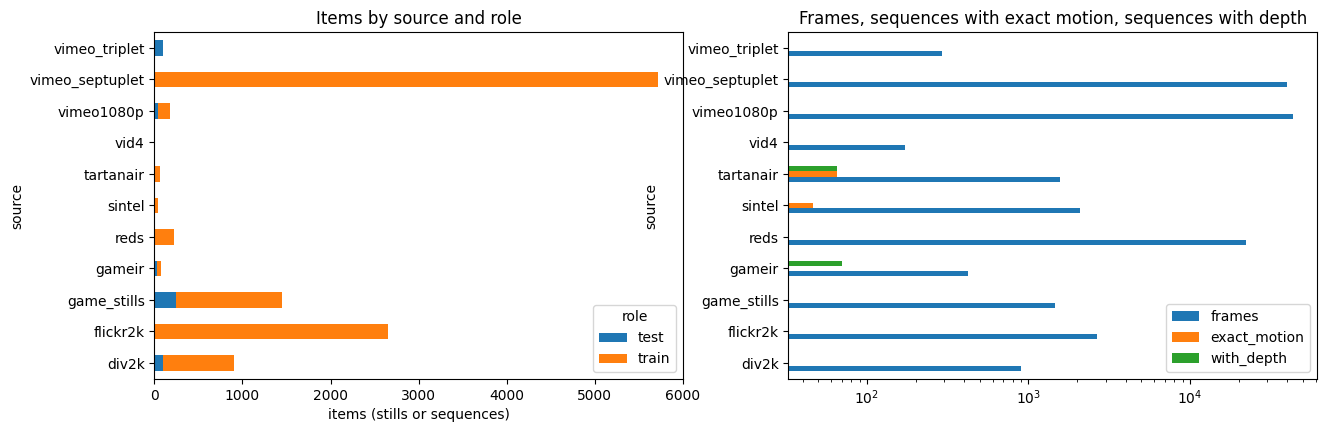

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
summary.pivot_table(
    index="source", columns="role", values="items", aggfunc="sum"
).fillna(0).plot.barh(ax=axes[0], stacked=True)
axes[0].set_xlabel("items (stills or sequences)")
axes[0].set_title("Items by source and role")
meta = summary.groupby("source")[["frames", "exact_motion", "with_depth"]].sum()
meta.plot.barh(ax=axes[1], logx=True)
axes[1].set_title("Frames, sequences with exact motion, sequences with depth")
RUN.show(fig, "catalogue")

## 8. Keyframe thumbnails and quality statistics

Decodes one keyframe per still or short clip and three (first, middle, last) per long sequence in a process pool over all CPU cores, keeping a 256x256 thumbnail and statistics: size, grey mean and contrast, Laplacian-variance sharpness, letterbox fraction and colourfulness. Expected output: a progress bar and a statistics table.

In [12]:
with RUN.stage("keyframe_stats"):
    THUMBS, KF = PL.keyframe_stats(ITEMS, DATA_ROOT, CFG["workers"])
KF["source"] = [ITEMS[i]["source"] for i in KF["item"]]
RUN.save_csv(KF, "keyframe_stats.csv", index=False)
print(
    KF.groupby("source")[
        ["width", "height", "std", "sharpness", "letterbox", "colourfulness"]
    ]
    .median()
    .round(2)
    .to_string()
)
print(f"keyframes: {len(KF)}, decode failures: {int((~KF['ok']).sum())}")

07:41:53 | start: keyframe_stats


Keyframe thumbnails and statistics:   0%|          | 0/12404 [00:00<?, ?it/s]

07:53:43 | done: keyframe_stats in 11.8 min (run total 2.71 h)
                  width  height    std  sharpness  letterbox  colourfulness
source                                                                     
div2k            2040.0  1356.0  58.22    1115.00        0.0          42.10
flickr2k         2040.0  1356.0  58.94    1147.64        0.0          42.49
game_stills      1920.0  1080.0  53.21     609.67        0.0          23.29
gameir           1920.0  1440.0  56.27     503.02        0.0          20.78
reds             1280.0   720.0  64.00    1080.98        0.0          31.88
sintel           1024.0   436.0  46.48     372.70        0.0          26.72
tartanair         640.0   480.0  55.98     704.75        0.0          23.78
vid4              720.0   528.0  55.89    1682.91        0.0          44.45
vimeo1080p       1920.0  1080.0  53.94     426.66        0.0          28.04
vimeo_septuplet   448.0   256.0  48.47     215.95        0.0          25.02
vimeo_triplet     448.0  

## 9. Filtering unsuitable data

Rejects items whose keyframes fail to decode or are smaller than 256 px, flat (grey standard deviation below 8), heavily letterboxed (more than 35 percent black rows) or blurry (median Laplacian variance below 20 for stills, 5 for video). Rejected items stay in the manifest with split `filtered`, so the decision is auditable. Expected output: rejection counts by reason and source, distributions with thresholds, and examples of rejected keyframes.

reason           blurry  flat  letterbox
source                                  
game_stills           2     3         26
tartanair             0     0          1
vimeo1080p            1    23         22
vimeo_septuplet      43    17         71
vimeo_triplet         1     0          0
kept 11219 of 11392 items


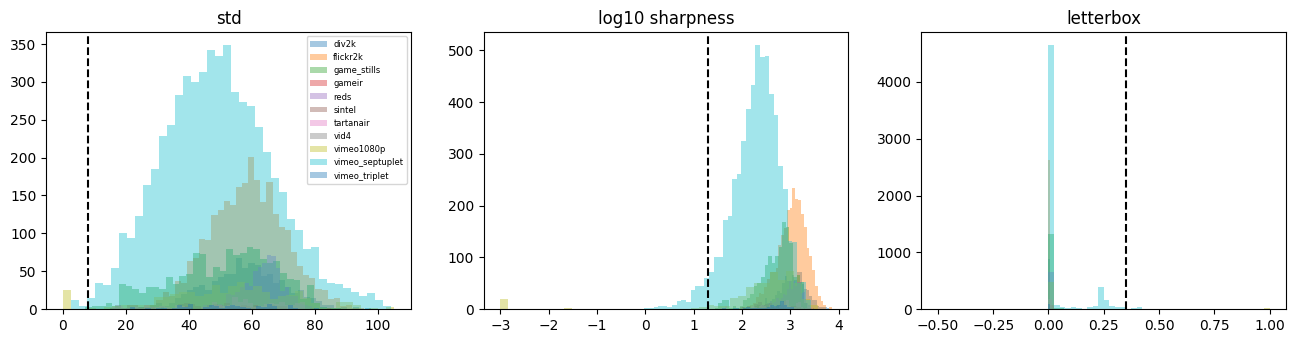

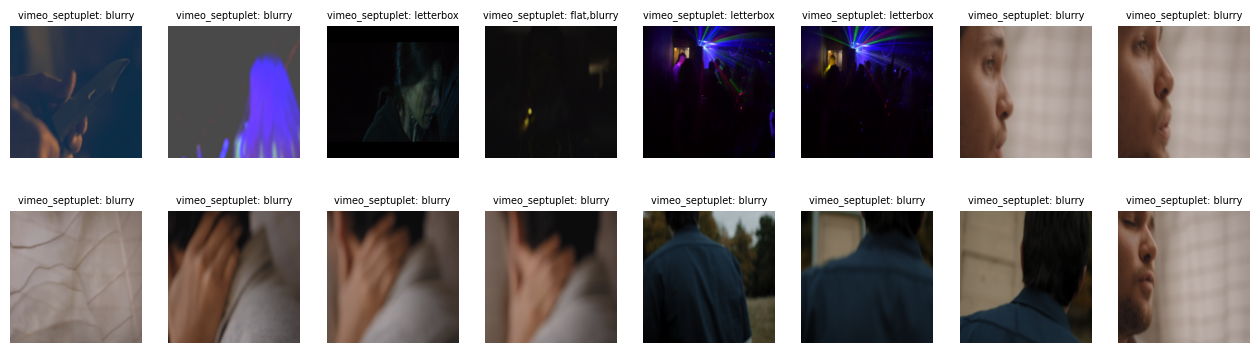

In [13]:
KEEP, REASONS = PL.apply_filters(ITEMS, KF)
rej = pd.DataFrame(
    [
        {"source": ITEMS[i]["source"], "reason": r}
        for i, rs in REASONS.items()
        for r in rs
    ]
)
if len(rej):
    print(rej.value_counts().unstack(fill_value=0).to_string())
print(f"kept {sum(KEEP)} of {len(ITEMS)} items")
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
for ax, (col, thr, logx) in zip(
    axes,
    [
        ("std", PL.FILTER_RULES["min_std"], False),
        ("sharpness", 20.0, True),
        ("letterbox", 0.35, False),
    ],
):
    for src, g in KF.groupby("source"):
        vals = g[col].dropna()
        ax.hist(np.log10(vals + 1e-3) if logx else vals, bins=40, alpha=0.4, label=src)
    ax.axvline(np.log10(thr) if logx else thr, color="k", ls="--")
    ax.set_title(f"{'log10 ' if logx else ''}{col}")
axes[0].legend(fontsize=6)
RUN.show(fig, "quality_distributions")
bad = [k for k, i in enumerate(KF["item"]) if not KEEP[i]][:16]
if bad:
    fig, axes = plt.subplots(2, 8, figsize=(16, 4.4))
    for ax in axes.flat:
        ax.axis("off")
    for ax, k in zip(axes.flat, bad):
        ax.imshow(THUMBS[k])
        ax.set_title(
            f"{KF['source'][k]}: {','.join(REASONS[KF['item'][k]])}", fontsize=7
        )
    RUN.show(fig, "rejected_examples")

## 10. Perceptual hashes

64-bit pHash (DCT of a 32x32 grey image, 8x8 low frequencies against their median) and dHash (horizontal gradient signs on 9x8) for every keyframe. pHash is robust to rescaling, mild compression and colour shifts but not to large crops or mirroring; embeddings cover those. Expected output: hash bit-balance check.

In [14]:
with RUN.stage("hashes"):
    PH, DH = PL.hashes(THUMBS)
print(
    f"pHash mean bit = {PH.mean():.3f}, dHash mean bit = {DH.mean():.3f} (about 0.5 means balanced bits)"
)

07:54:02 | start: hashes
07:54:09 | done: hashes in 0.1 min (run total 2.71 h)
pHash mean bit = 0.499, dHash mean bit = 0.479 (about 0.5 means balanced bits)


## 11. Embeddings on both GPUs

DINOv2-small (Apache 2.0) global descriptors (384-d, L2-normalised) for every thumbnail, batches split across the two GPUs with one thread per GPU. Self-supervised descriptors are the strongest general-purpose features for near-duplicate and copy detection after dedicated copy-detection models. Falls back to hashes only if the weights cannot be downloaded. Expected output: embedding matrix shape and throughput.

In [15]:
with RUN.stage("embeddings"):
    EMBEDDERS = []
    for dvc in DEVICES:
        e, name = DD.load_embedder(dvc, log=log)
        if e is None:
            EMBEDDERS = []
            break
        EMBEDDERS.append(e)
    t0 = time.time()
    EMB = DD.embed_thumbs(THUMBS, EMBEDDERS, DEVICES) if EMBEDDERS else None
log(f"embeddings: {None if EMB is None else EMB.shape} in {time.time() - t0:.0f} s")

07:54:09 | start: embeddings


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

07:54:31 | done: embeddings in 0.4 min (run total 2.72 h)
07:54:31 | embeddings: (12404, 384) in 15 s


## 12. Threshold calibration

Positive pairs are synthetic near-duplicates of random keyframes (60 to 95 percent crops, rescale, optional mirror, small rotation, colour and brightness shift, blur, text overlay, JPEG quality 35 to 92); negatives are random pairs of different keyframes. An all-pairs search tests hundreds of millions of pairs, so a threshold tuned only to a 0.1 percent false-positive rate would flag far too many unrelated pairs. Each threshold is therefore the stricter of the `max_fpr` point and the most similar negative plus a margin; recall at the final threshold shows what that strictness costs. Expected output: thresholds with precision, recall and F1 at the `max_fpr` point and recall at the final threshold, ROC curves and the Hamming histogram.

07:54:32 | start: calibration
07:55:03 | done: calibration in 0.5 min (run total 2.73 h)
           threshold  precision  recall      f1  recall_at_threshold
phash        14.0000     0.9871  0.3060  0.4672               0.2407
embedding     0.6407     0.9960  0.9953  0.9957               0.9573


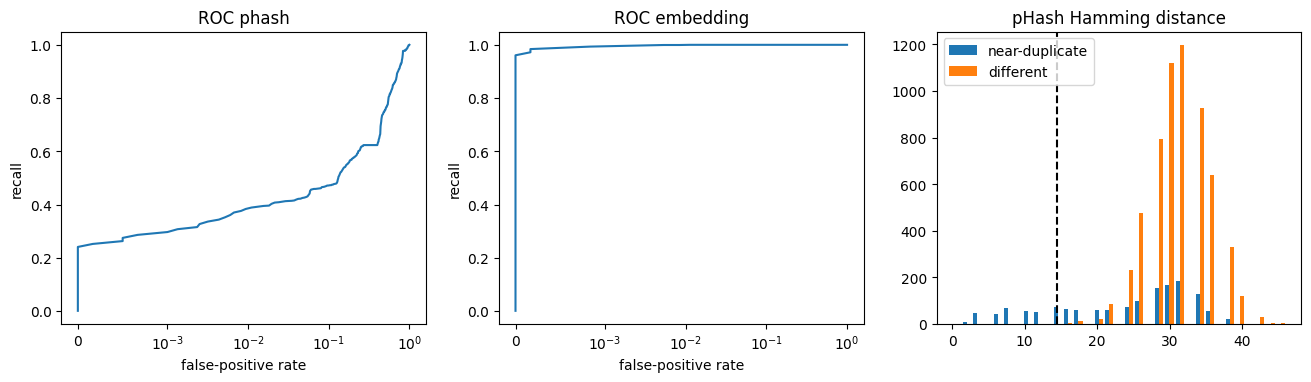

In [16]:
with RUN.stage("calibration"):
    THR = PL.calibrate(
        THUMBS,
        EMBEDDERS,
        DEVICES,
        CFG["calibration_pairs"],
        CFG["seed"],
        CFG["max_fpr"],
    )
cal = {
    k: {
        m: v[m]
        for m in ("threshold", "precision", "recall", "f1", "recall_at_threshold")
    }
    for k, v in THR.items()
    if isinstance(v, dict)
}
cal["phash"]["threshold"] = THR["phash"][
    "hamming"
]  # Hamming distance (bits) rather than the negated score
RUN.save_json(cal, "dedup_calibration.json")
print(pd.DataFrame(cal).T.round(4).to_string())
labels = np.array(THR["labels"])
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for key, ax in (("phash", axes[0]), ("embedding", axes[1])):
    if key in THR:
        ax.plot(THR[key]["roc"]["fpr"], THR[key]["roc"]["tpr"])
        ax.set_xscale("symlog", linthresh=1e-3)
        ax.set_title(f"ROC {key}")
        ax.set_xlabel("false-positive rate")
        ax.set_ylabel("recall")
ham = np.array(THR["phash_scores"])
axes[2].hist(
    [ham[labels == 1], ham[labels == 0]], bins=33, label=["near-duplicate", "different"]
)
axes[2].axvline(THR["phash"]["hamming"] + 0.5, color="k", ls="--")
axes[2].set_title("pHash Hamming distance")
axes[2].legend()
RUN.show(fig, "dedup_calibration")

## 13. Near-duplicate search across the combined dataset

Exhaustive search over all keyframe pairs on the GPU: pHash Hamming distances become dot products of +-1 vectors, embeddings use cosine similarity, both computed in chunked half-precision matrix products. pHash matches count only between keyframes with enough structure (grey standard deviation at least 15) and must be confirmed by dHash, because dark or flat frames share hashes by accident. If a method still yields more than two edges per keyframe, its threshold is tightened step by step (an implausible duplicate rate means false positives, which would merge unrelated data into giant components). Pairs inside one item are ignored. Expected output: final thresholds, pairs per method, a cross-source duplicate matrix (which datasets overlap) and examples of detected pairs for visual verification.

07:55:04 | start: duplicate_search
07:55:05 | done: duplicate_search in 0.0 min (run total 2.73 h)
final thresholds: pHash Hamming <= 14, cosine >= 0.7506718683242799
method
embedding    23576
phash         7614
b                div2k  flickr2k  game_stills  gameir  reds  sintel  tartanair  vid4  vimeo1080p  vimeo_septuplet  vimeo_triplet
a                                                                                                                               
div2k              100       195           50       1     9       5          5     1          19              138              3
flickr2k             0      2495          120       2    31       9          9     0          51              376              7
game_stills          0         0        13019       3     0       0          9     0          32                0              0
gameir               0         0            0      91     0       0          0     0           1                0              0
reds          

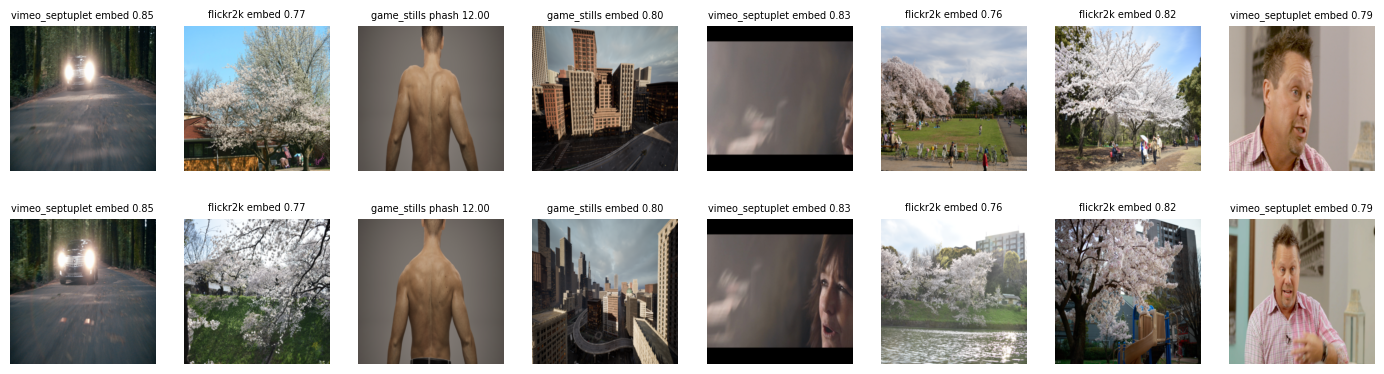

In [17]:
with RUN.stage("duplicate_search"):
    PAIRS = PL.find_duplicates(KF, PH, EMB, THR, DEVICES[0], dhash=DH)
RUN.save_csv(PAIRS, "duplicate_pairs.csv", index=False)
print(
    f"final thresholds: pHash Hamming <= {THR['phash']['hamming_final']}, "
    f"cosine >= {THR.get('embedding', {}).get('threshold_final')}"
)
print(
    PAIRS["method"].value_counts().to_string() if len(PAIRS) else "no duplicate pairs"
)
if len(PAIRS):
    src_a = [ITEMS[i]["source"] for i in PAIRS["item_a"]]
    src_b = [ITEMS[i]["source"] for i in PAIRS["item_b"]]
    mat = pd.crosstab(pd.Series(src_a, name="a"), pd.Series(src_b, name="b"))
    print(mat.to_string())
    show_pairs = (
        PAIRS.sort_values("score", ascending=False)
        .drop_duplicates(["item_a", "item_b"])
        .sample(n=min(8, len(PAIRS)), random_state=0)
    )
    fig, axes = plt.subplots(
        2, len(show_pairs), figsize=(2.2 * len(show_pairs), 4.6), squeeze=False
    )
    for c, (_, r) in enumerate(show_pairs.iterrows()):
        for row, kf_col in ((0, "kf_a"), (1, "kf_b")):
            axes[row, c].imshow(THUMBS[r[kf_col]])
            axes[row, c].axis("off")
            axes[row, c].set_title(
                f"{KF['source'][r[kf_col]]} {r['method'][:5]} {r['score']:.2f}",
                fontsize=7,
            )
    RUN.show(fig, "duplicate_examples")

## 14. Clustering and leakage-safe split

Union-find over (a) structural edges: items sharing a leakage group (same sequence, video, Sintel scene family, TartanAir environment, GameIR town) and (b) near-duplicate edges. Each connected component receives one split: components containing a test item become test and any training-role members are dropped; the rest go to validation with probability `val_fraction` (deterministic hash) or to training. Expected output: the split report and per-source split counts.

In [18]:
REPORT = PL.split_items(ITEMS, PAIRS, CFG["val_fraction"], CFG["seed"])
for it, k in zip(ITEMS, KEEP):
    if not k:
        it["split"] = "filtered"
RUN.save_json(REPORT, "split_report.json")
print(pd.Series(REPORT).to_string())
split_table = pd.crosstab(
    pd.Series([i["source"] for i in ITEMS], name="source"),
    pd.Series([i["split"] for i in ITEMS], name="split"),
)
RUN.save_csv(split_table, "split_by_source.csv")
print(split_table.to_string())

items                                                                               11392
components                                                                           2527
largest_component                                                                    8354
dup_edges                                                                           31190
train_items_dropped_for_test_leakage                                                 8150
split_counts                            {'train': 2567, 'val': 134, 'test': 541, 'drop...
split            drop  filtered  test  train  val
source                                           
div2k             212         0   100    558   30
flickr2k          754         0     0   1806   90
game_stills      1081        28   243     88   10
gameir             40         0    30      0    0
reds              119         0     0     98    4
sintel             32         0    10      4    0
tartanair          55         1     9      0    0
vid4      

## 15. Leakage audit

For every validation and test keyframe, the most similar training keyframe (cosine) and the closest pHash (Hamming). After the split no cross-split pair may pass the final embedding threshold (asserted); pHash matches are reported, since low-structure frames are excluded from pHash edges by design. Expected output: audit statistics, histograms and violation counts.

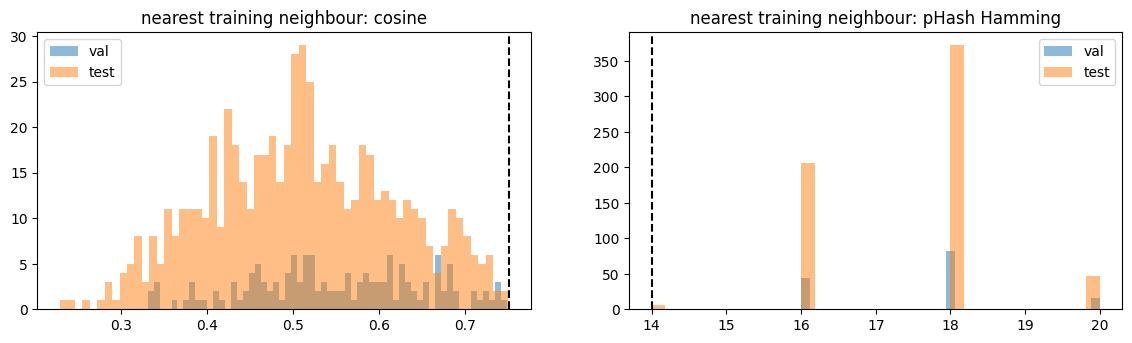

split                     metric       max       p99
  val        max cosine to train  0.748535  0.740522
  val min pHash Hamming to train 16.000000 16.000000
 test        max cosine to train  0.750000  0.727588
 test min pHash Hamming to train 14.000000 16.000000
val_phash_matches         0
val_embedding_matches     0
test_phash_matches        6
test_embedding_matches    0


In [19]:
AUDIT = PL.cross_split_audit(KF, ITEMS, EMB, PH, DEVICES[0])
rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
for s, res in AUDIT.items():
    if "max_cosine_to_train" in res:
        axes[0].hist(res["max_cosine_to_train"], bins=60, alpha=0.5, label=s)
        rows.append(
            {
                "split": s,
                "metric": "max cosine to train",
                "max": float(res["max_cosine_to_train"].max()),
                "p99": float(np.percentile(res["max_cosine_to_train"], 99)),
            }
        )
    axes[1].hist(res["min_hamming_to_train"], bins=33, alpha=0.5, label=s)
    rows.append(
        {
            "split": s,
            "metric": "min pHash Hamming to train",
            "max": float(res["min_hamming_to_train"].min()),
            "p99": float(np.percentile(res["min_hamming_to_train"], 1)),
        }
    )
if "embedding" in THR:
    axes[0].axvline(THR["embedding"]["threshold_final"], color="k", ls="--")
axes[1].axvline(THR["phash"]["hamming_final"], color="k", ls="--")
axes[0].set_title("nearest training neighbour: cosine")
axes[1].set_title("nearest training neighbour: pHash Hamming")
for ax in axes:
    ax.legend()
RUN.show(fig, "leakage_audit")
audit = pd.DataFrame(rows)
RUN.save_csv(audit, "leakage_audit.csv", index=False)
print(audit.to_string(index=False))
violations = {}
for s, res in AUDIT.items():
    violations[f"{s}_phash_matches"] = int(
        (res["min_hamming_to_train"] <= THR["phash"]["hamming_final"]).sum()
    )
    if "max_cosine_to_train" in res and "embedding" in THR:
        violations[f"{s}_embedding_matches"] = int(
            (res["max_cosine_to_train"] >= THR["embedding"]["threshold_final"]).sum()
        )
RUN.save_json(violations, "leakage_violations.json")
print(pd.Series(violations).to_string())
assert all(
    v == 0 for k, v in violations.items() if "embedding" in k
), "cross-split embedding duplicates remain"

## 16. Manifest and dataset card

Saves the manifest (`nss_data/nss_manifest.parquet`) and a dataset card listing every source with its host, licence statement, content type, item counts per split and whether it carries exact motion vectors or depth. Licences are as stated by the hosting page; several research datasets restrict commercial use (see `RESEARCH.md`). Expected output: the card table.

In [20]:
D.save_manifest(ITEMS, DATA_ROOT / "nss_manifest.parquet")
card = []
for s in D.SOURCES:
    its = [i for i in ITEMS if i["source"] == s["name"]]
    card.append(
        {
            "source": s["name"],
            "host": s["host"],
            "id": s.get("ref") or s.get("repo"),
            "licence": s["licence"],
            "content": s.get("content"),
            "items": len(its),
            **{
                sp: sum(i["split"] == sp for i in its)
                for sp in ("train", "val", "test", "drop", "filtered")
            },
            "exact_motion": any(i.get("mv") == "exact_forward" for i in its),
            "depth": any(bool(i.get("depth")) for i in its),
        }
    )
card = pd.DataFrame(card)
RUN.save_csv(card, "dataset_card.csv", index=False)
print(card.to_string(index=False))

         source   host                                         id                                                   licence  content  items  train  val  test  drop  filtered  exact_motion  depth
          div2k kaggle soumikrakshit/div2k-high-resolution-images                              DIV2K: academic research use    photo    900    558   30   100   212         0         False  False
       flickr2k kaggle                         daehoyang/flickr2k Flickr2K: research use (Flickr images, original licences)    photo   2650   1806   90     0   754         0         False  False
           reds kaggle           amithkesavmrajagiri/reds-dataset                                           REDS: CC BY 4.0    video    221     98    4     0   119         0         False  False
vimeo_septuplet kaggle                      wangsally/vimeo-90k-7                   Vimeo-90K: research use (Vimeo uploads)    video   5715      0    0     0  5598       117         False  False
  vimeo_triplet kaggle   

## 17. Summary

Stage times against the budget and the headline numbers of the pipeline. Expected output: a summary table and a stage-time bar chart.

items                         11392.000000
keyframes                     12404.000000
duplicate_pairs               31190.000000
train                          2567.000000
val                             134.000000
test                            541.000000
drop                           8150.000000
train_dropped_for_leakage      8150.000000
phash_hamming_threshold          14.000000
embedding_cosine_threshold        0.750672
data_root_gb                     13.390000
run_hours                         2.730000


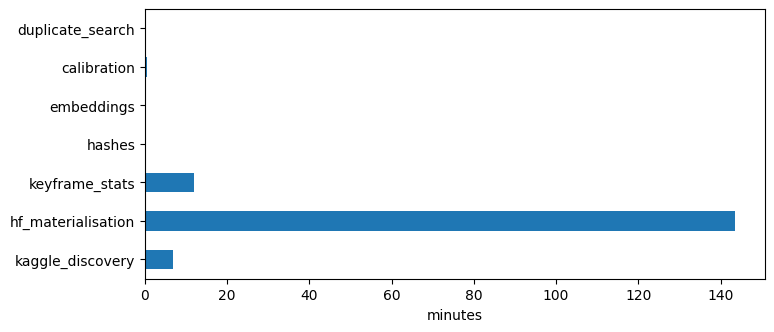

In [21]:
summary = {
    "items": len(ITEMS),
    "keyframes": len(KF),
    "duplicate_pairs": int(len(PAIRS)),
    **REPORT["split_counts"],
    "train_dropped_for_leakage": REPORT["train_items_dropped_for_test_leakage"],
    "phash_hamming_threshold": THR["phash"]["hamming_final"],
    "embedding_cosine_threshold": THR.get("embedding", {}).get("threshold_final"),
    "data_root_gb": round(used_gb, 2),
    "run_hours": round(RUN.hours(), 2),
}
RUN.save_json(summary, "summary.json")
print(pd.Series(summary).to_string())
st = pd.Series(RUN.stage_times) / 60
RUN.save_csv(st.rename("minutes").to_frame(), "stage_times.csv")
fig, ax = plt.subplots(figsize=(8, 3.5))
st.plot.barh(ax=ax)
ax.set_xlabel("minutes")
RUN.show(fig, "stage_times")

## 18. Package reports

Zips metrics, plots, logs and code into `outputs.zip` (the materialised data in `nss_data/` is excluded because it is already part of this notebook's Output and is consumed from there). After **Save Version > Save & Run All**, the zip and all files also appear in the notebook's **Output** tab.

In [22]:
import shutil
import zipfile

from IPython.display import FileLink, display
from tqdm.auto import tqdm

WORK = C.WORK
ZIP_PATH = WORK / "outputs.zip"
EXCLUDE_PARTS = {
    "__pycache__",
    ".ipynb_checkpoints",
    ".cache",
    "nss_data",
    "tmp",
    "wandb",
}
STORED_SUFFIXES = {
    ".zip",
    ".png",
    ".jpg",
    ".jpeg",
    ".pt",
    ".pth",
    ".bin",
    ".safetensors",
    ".gz",
    ".npz",
    ".onnx",
    ".mp4",
    ".parquet",
}
files = [
    p
    for p in WORK.rglob("*")
    if p.is_file()
    and p != ZIP_PATH
    and not EXCLUDE_PARTS.intersection(p.relative_to(WORK).parts)
]
total_bytes = sum(p.stat().st_size for p in files)
free_bytes = shutil.disk_usage(WORK).free
assert (
    free_bytes > total_bytes * 1.05
), f"Not enough disk space to zip {total_bytes / 1e9:.2f} GB with {free_bytes / 1e9:.2f} GB free."
with zipfile.ZipFile(ZIP_PATH, "w", allowZip64=True) as archive:
    for p in tqdm(files, desc="Zipping outputs", unit="file"):
        method = (
            zipfile.ZIP_STORED
            if p.suffix.lower() in STORED_SUFFIXES
            else zipfile.ZIP_DEFLATED
        )
        archive.write(p, p.relative_to(WORK), compress_type=method)
print(
    f"Zipped {len(files)} files ({total_bytes / 1e9:.2f} GB) into {ZIP_PATH}",
    flush=True,
)
display(FileLink(os.path.relpath(ZIP_PATH)))

Zipping outputs:   0%|          | 0/27 [00:00<?, ?file/s]

Zipped 27 files (0.01 GB) into /kaggle/working/outputs.zip


/kaggle/working/outputs.zip